# A loss harness you can read

(Built as ERA V5 Session 9 assignment.) The starting point is the textbook four-line loss:

```python
hidden = model(tokens)
logits = output_head(hidden)
loss = cross_entropy(
    logits[:, :-1].reshape(-1, vocab_size),
    tokens[:, 1:].reshape(-1),
)
```

and asks for them to be made **correct and observable**. This notebook builds a small GPT
(6 layers, d=384, GPT-2 tokenizer, tied head), trains it on ~20M tokens of FineWeb-Edu, and makes every step between
`hidden` and the scalar loss visible:

| Part 1 | What is shown |
|---|---|
| 1.1 | every tensor shape on the way from token ids to the scalar, with what each dimension means |
| 1.2 | the next-token shift as **decoded strings**, plus a programmatic check that fails on a wrong shift |
| 1.3 | padding excluded from the loss, contributing-token count before/after |
| 1.4 | two documents packed into one sequence; the boundary target masked; loss before/after |
| 1.5 | perplexity of the untrained model against the vocabulary size |
| 1.6 | tied vs untied head parameter counts for this configuration |
| 1.7 | peak memory of ordinary vs chunked cross-entropy (chunked version written here, with its own backward) |

**Part 2** adds a second output head that predicts token `t+2`, trains it next to the normal head, and tracks
both losses over training. A deliberately wrong-shift run is included as a control, because the main
warning is that a shift in the wrong direction produces a beautiful loss curve.

All numbers quoted in the README come from this notebook's outputs and from `results/metrics.json`, which the last
cell writes.

## 0. Setup

The notebook runs on a GPU (it was executed on a Modal T4 via `modal_run.py`) and also opens in Colab or plain
Jupyter. `S9_QUICK=1` shrinks data and step counts for smoke tests; the committed run uses `QUICK = False`.

In [1]:
import os, sys, math, json, time, random, gc, platform, importlib.util, subprocess
from pathlib import Path

for _pkg in ("tiktoken", "datasets"):          # Colab has torch/numpy/pandas/matplotlib already
    if importlib.util.find_spec(_pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pkg])

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
import matplotlib.pyplot as plt
from IPython.display import display

QUICK = os.environ.get("S9_QUICK", "0") == "1"
SEED = 1337
device = "cuda" if torch.cuda.is_available() else "cpu"
RESULTS, FIGS = Path("results"), Path("figures")
RESULTS.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)
METRICS = {}                                     # everything reported in the README is collected here

def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything()
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

# one small, consistent plot style (categorical slots: blue = t+1 head, orange = t+2 head, aqua = summed objective)
C_T1, C_T2, C_SUM, C_REF, C_BUG = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#e34948"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#8a8984",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titlesize": 11, "axes.titleweight": "bold", "lines.linewidth": 2, "legend.frameon": False,
})

ENV = {
    "python": platform.python_version(), "torch": torch.__version__, "cuda": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0) if device == "cuda" else "none (CPU)",
    "tiktoken": tiktoken.__version__, "numpy": np.__version__, "quick_mode": QUICK, "seed": SEED,
}
print(json.dumps(ENV, indent=2))

{
  "python": "3.11.12",
  "torch": "2.5.1+cu124",
  "cuda": "12.4",
  "gpu": "Tesla T4",
  "tiktoken": "0.8.0",
  "numpy": "2.1.3",
  "quick_mode": false,
  "seed": 1337
}


In [2]:
CFG = dict(
    vocab_size=50257,          # GPT-2 BPE as-is (not padded to 50304), so the ln(V) anchor is exactly ln(50257)
    block_size=256,            # T: tokens per training window
    n_layer=6, n_head=6, n_embd=384, ffn_hidden=1024,   # SwiGLU width 1024 = 8/3 * 384
    batch_size=32,             # B: windows per step -> 8,192 positions per step
    max_lr=1e-3, min_lr=1e-4, warmup_steps=100, weight_decay=0.1, grad_clip=1.0,
    train_tokens=20_000_000, val_tokens=500_000,
    eval_every=100, eval_batches=40,      # 40 x 32 x 256 = 327,680 validation positions per evaluation
    wrong_shift_steps=300,     # length of the deliberately broken control run
    ce_chunk=1024,             # chunk size for the chunked cross-entropy (1,024)
)
if globals().get("QUICK", False):
    CFG.update(train_tokens=300_000, val_tokens=80_000, eval_every=10, eval_batches=4, wrong_shift_steps=20)
B, T, D, V = CFG["batch_size"], CFG["block_size"], CFG["n_embd"], CFG["vocab_size"]
IGNORE = -100                  # target value that cross_entropy skips (ignore_index)
print(CFG)

{'vocab_size': 50257, 'block_size': 256, 'n_layer': 6, 'n_head': 6, 'n_embd': 384, 'ffn_hidden': 1024, 'batch_size': 32, 'max_lr': 0.001, 'min_lr': 0.0001, 'warmup_steps': 100, 'weight_decay': 0.1, 'grad_clip': 1.0, 'train_tokens': 20000000, 'val_tokens': 500000, 'eval_every': 100, 'eval_batches': 40, 'wrong_shift_steps': 300, 'ce_chunk': 1024}


### Tokenizer

GPT-2's BPE via `tiktoken`. It has no padding token; `<|endoftext|>` (id 50256) ends every document. Where padding
is needed (1.3) the pad *id* is irrelevant, because the mask is built from sequence lengths, never from the id.

`tok_str` prints a single token with quotes so leading spaces are visible: `" capital"` is a different token from
`"capital"`.

In [3]:
enc = tiktoken.get_encoding("gpt2")
EOT = enc.eot_token
assert enc.n_vocab == V, (enc.n_vocab, V)

def tok_str(i):
    s = enc.decode([int(i)])
    return '"' + s.replace("\n", "\\n").replace("\t", "\\t") + '"'

print("EOT id:", EOT, tok_str(EOT))
print([tok_str(i) for i in enc.encode_ordinary("The capital of India is New Delhi.")])

EOT id: 50256 "<|endoftext|>"
['"The"', '" capital"', '" of"', '" India"', '" is"', '" New"', '" Delhi"', '"."']


## 1. Data: FineWeb-Edu, packed into windows with document ids

The first documents of the `sample-10BT` stream of `HuggingFaceFW/fineweb-edu` (deterministic order) are
tokenized, each followed by `<|endoftext|>`. The first ~0.5M tokens worth of documents are held out for validation,
the next ~20M are training data (a suggested scale for this exercise: a small model on 10–20M tokens).

Documents are concatenated and cut into fixed windows of `T = 256` tokens (standard packing). Next to the token
array the loader keeps a **document id for every position**. That array is what lets the harness find the
boundaries later: a target is only legitimate if the input position and the target position belong to the same
document.

In [4]:
def load_fineweb_edu(n_tokens):
    from datasets import load_dataset
    stream = load_dataset("HuggingFaceFW/fineweb-edu", name="sample-10BT", split="train", streaming=True)
    docs, total, buf = [], 0, []
    for ex in stream:
        buf.append(ex["text"])
        if len(buf) == 256:
            for ids in enc.encode_ordinary_batch(buf):
                docs.append(ids + [EOT]); total += len(ids) + 1
            buf = []
            if total >= n_tokens:
                break
    return docs

t0 = time.time()
docs = load_fineweb_edu(CFG["val_tokens"] + CFG["train_tokens"])
val_docs, train_docs, seen = [], [], 0
for d in docs:
    (val_docs if seen < CFG["val_tokens"] else train_docs).append(d)
    seen += len(d)
print(f"downloaded + tokenized {len(docs):,} documents ({seen:,} tokens) in {time.time() - t0:.0f}s")

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


downloaded + tokenized 19,968 documents (20,711,061 tokens) in 23s


In [5]:
class PackedSplit:
    """Documents concatenated (each ends with <|endoftext|>) and cut into fixed T-token windows.
    doc_ids[w, t] says which document position t of window w came from."""

    def __init__(self, docs, T, first_doc_id=0):
        toks = np.concatenate([np.asarray(d, dtype=np.int64) for d in docs])
        ids = np.repeat(np.arange(first_doc_id, first_doc_id + len(docs)), [len(d) for d in docs])
        n = len(toks) // T                         # the ragged tail is dropped
        self.tokens = torch.from_numpy(toks[: n * T]).view(n, T)
        self.doc_ids = torch.from_numpy(ids[: n * T]).view(n, T)
        self.n_windows, self.n_docs = n, len(docs)

    def get(self, idx):
        return self.tokens[idx].to(device), self.doc_ids[idx].to(device)

    def stats(self):
        crossings = (self.doc_ids[:, 1:] != self.doc_ids[:, :-1]).sum(1)
        return {"documents": self.n_docs, "windows": self.n_windows, "tokens_in_windows": self.n_windows * self.tokens.shape[1],
                "windows_with_a_boundary": round(float((crossings > 0).float().mean()), 3),
                "boundaries_per_window": round(float(crossings.float().mean()), 3)}

In [6]:
val_split = PackedSplit(val_docs, T, first_doc_id=0)
train_split = PackedSplit(train_docs, T, first_doc_id=len(val_docs))
doc_lens = np.array([len(d) for d in train_docs])
data_stats = pd.DataFrame({"train": train_split.stats(), "val": val_split.stats()})
display(data_stats)
print(f"train doc length: median {np.median(doc_lens):.0f} tokens, mean {doc_lens.mean():.0f}")
METRICS["data"] = {"source": "HuggingFaceFW/fineweb-edu sample-10BT (stream order)",
                   "train": train_split.stats(), "val": val_split.stats()}
del docs

,train,val
documents,1.944300e+04,525.000
windows,7.894700e+04,1954.000
tokens_in_windows,2.021043e+07,500224.000
windows_with_a_boundary,2.340000e-01,0.252
boundaries_per_window,2.450000e-01,0.268


train doc length: median 620 tokens, mean 1039


## 2. The model

A nanoGPT-shaped decoder built from standard pieces: pre-norm blocks with **RMSNorm**,
causal self-attention, a **SwiGLU** feed-forward network, a residual stream, a final RMSNorm, and an output head
`Linear(D, V)` **tied** to the token embedding.

Two details matter for the harness:

* `forward(tokens, doc_ids)` uses a **document-aware causal mask** when `doc_ids` is given: position `t` attends to
  `s ≤ t` only if both are in the same document, and position embeddings restart at every document. The point is that the loss mask and the attention mask must agree; with both in place, a packed window behaves
  exactly like its documents run separately (checked in 1.4).
* `n_future=2` adds a second head for `t+2`. It cannot share the tied matrix: two heads reading the same hidden
  state through the same matrix would produce identical logits. So the extra head is its own dense `[V, D]`
  matrix, which is the cost of an extra head.

In [7]:
def positions_within_doc(doc_ids):
    """Position of every token inside its own document (restarts at 0 at each boundary)."""
    Bn, Tn = doc_ids.shape
    idx = torch.arange(Tn, device=doc_ids.device).expand(Bn, Tn)
    starts = torch.ones_like(doc_ids, dtype=torch.bool)
    starts[:, 1:] = doc_ids[:, 1:] != doc_ids[:, :-1]
    return idx - torch.where(starts, idx, torch.zeros_like(idx)).cummax(dim=1).values

def doc_causal_mask(doc_ids):
    """[B, 1, T, T] boolean: may query t attend to key s?  (s <= t) AND same document."""
    Tn = doc_ids.shape[1]
    causal = torch.ones(Tn, Tn, dtype=torch.bool, device=doc_ids.device).tril()
    same_doc = doc_ids[:, :, None] == doc_ids[:, None, :]
    return (causal & same_doc)[:, None]


class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.n_head, self.d = cfg["n_head"], cfg["n_embd"]
        self.qkv = nn.Linear(self.d, 3 * self.d, bias=False)
        self.proj = nn.Linear(self.d, self.d, bias=False)

    def split_heads(self, x):
        Bn, Tn, _ = x.shape
        q, k, v = self.qkv(x).split(self.d, dim=2)
        return [z.view(Bn, Tn, self.n_head, self.d // self.n_head).transpose(1, 2) for z in (q, k, v)]

    def forward(self, x, attn_mask=None):
        Bn, Tn, _ = x.shape
        q, k, v = self.split_heads(x)
        if attn_mask is None:
            y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        else:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=attn_mask)
        return self.proj(y.transpose(1, 2).reshape(Bn, Tn, self.d))


class SwiGLU(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d, f = cfg["n_embd"], cfg["ffn_hidden"]
        self.gate, self.up, self.down = nn.Linear(d, f, bias=False), nn.Linear(d, f, bias=False), nn.Linear(f, d, bias=False)

    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))


class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.norm1, self.attn = nn.RMSNorm(cfg["n_embd"]), CausalSelfAttention(cfg)
        self.norm2, self.ffn = nn.RMSNorm(cfg["n_embd"]), SwiGLU(cfg)

    def forward(self, x, attn_mask=None):
        x = x + self.attn(self.norm1(x), attn_mask)     # pre-norm: the residual stream itself is never normalised
        x = x + self.ffn(self.norm2(x))
        return x


class GPT(nn.Module):
    def __init__(self, cfg, tied=True, n_future=1):
        super().__init__()
        d, v = cfg["n_embd"], cfg["vocab_size"]
        self.cfg, self.tied, self.n_future = cfg, tied, n_future
        self.wte = nn.Embedding(v, d)
        self.wpe = nn.Embedding(cfg["block_size"], d)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg["n_layer"])])
        self.norm_f = nn.RMSNorm(d)
        # heads[0] predicts t+1, heads[1] (if present) predicts t+2
        self.heads = nn.ModuleList([nn.Linear(d, v, bias=False)])
        if tied:
            self.heads[0].weight = self.wte.weight      # one [V, D] tensor used for reading in and scoring out
        self.apply(self._init)
        for name, p in self.named_parameters():
            if name.endswith("attn.proj.weight") or name.endswith("ffn.down.weight"):
                nn.init.normal_(p, 0.0, 0.02 / math.sqrt(2 * cfg["n_layer"]))
        # extra heads are built and initialised last, so the trunk and head 1 draw identical random numbers
        # whether or not they exist (the baseline and mtp runs start from the same shared weights)
        for _ in range(n_future - 1):
            extra = nn.Linear(d, v, bias=False)
            nn.init.normal_(extra.weight, 0.0, 0.02)
            self.heads.append(extra)

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, 0.0, 0.02)

    def forward(self, tokens, doc_ids=None, with_logits=True):
        Bn, Tn = tokens.shape
        if doc_ids is None:
            pos, mask = torch.arange(Tn, device=tokens.device).expand(Bn, Tn), None
        else:
            pos, mask = positions_within_doc(doc_ids), doc_causal_mask(doc_ids)
        x = self.wte(tokens) + self.wpe(pos)
        for blk in self.blocks:
            x = blk(x, mask)
        hidden = self.norm_f(x)
        logits = [head(hidden) for head in self.heads] if with_logits else None
        return hidden, logits


def count_params(model):
    return sum(p.numel() for p in model.parameters())     # parameters() yields each shared tensor once

## 3. The harness

Everything that touches targets lives in four small functions, and the training loop uses exactly these.

* `build_targets(tokens, k, valid, doc_ids)` returns a `[B, T]` tensor whose entry at `t` is the token at `t+k`,
  or `IGNORE` when that prediction is not legitimate: `t+k` falls outside the window, either position is
  padding, or the two positions belong to different documents. `k=1` is the ordinary next-token target; `k=2` is
  the Part 2 head.
* `masked_ce(logits, targets)` sums cross-entropy over contributing positions and divides by **their count**, not
  by `B·T`. It returns that count so it can be printed.
* `check_alignment(tokens, targets, k)` is the machine check: every target that is not `IGNORE` must equal the
  token exactly `k` positions later in the same row.
* `alignment_table(...)` prints inputs beside targets as decoded strings, and says *why* each masked target is
  masked.

Keeping `[B, T]` targets instead of slicing `logits[:, :-1]` lets one function serve `t+1`, `t+2`, padding and
boundaries. 1.2 checks that it equals the textbook slicing formula when there is nothing to mask.

In [8]:
def build_targets(tokens, k=1, valid=None, doc_ids=None):
    """targets[b, t] = tokens[b, t+k] if that is a legitimate prediction, else IGNORE.
    Legitimate: t+k inside the window, positions t and t+k both real tokens (valid), same document.
    k=1 -> next token, k=2 -> the Part 2 head. Negative k is used only for the deliberately wrong control."""
    Bn, Tn = tokens.shape
    src = slice(0, Tn - k) if k > 0 else slice(-k, Tn)     # positions t whose t+k lies inside the window
    dst = slice(k, Tn) if k > 0 else slice(0, Tn + k)
    tgt = torch.full_like(tokens, IGNORE)
    ok = torch.zeros((Bn, Tn), dtype=torch.bool, device=tokens.device)
    tgt[:, src] = tokens[:, dst]
    ok[:, src] = True
    if valid is not None:
        ok[:, src] &= valid[:, src] & valid[:, dst]
    if doc_ids is not None:
        ok[:, src] &= doc_ids[:, src] == doc_ids[:, dst]
    return tgt.masked_fill(~ok, IGNORE)


def masked_ce(logits, targets):
    """Mean cross-entropy over contributing positions. Returns (loss, n_contributing, per_position_ce)."""
    logits = logits.to(torch.promote_types(logits.dtype, torch.float32))     # fp16 -> fp32; never downcast
    per_pos = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1),
                              ignore_index=IGNORE, reduction="none").view(targets.shape)
    n = (targets != IGNORE).sum()
    return per_pos.sum() / n.clamp_min(1), n, per_pos


def check_alignment(tokens, targets, k):
    """Every non-ignored target must be the token exactly k positions later in the same row."""
    b, t = (targets != IGNORE).nonzero(as_tuple=True)
    if len(t) == 0:
        return False, "no contributing targets at all"
    inside = ((t + k) >= 0) & ((t + k) < tokens.shape[1])
    outside = int((~inside).sum())
    b_in, t_in = b[inside], t[inside]
    bad = int((targets[b_in, t_in] != tokens[b_in, t_in + k]).sum()) + outside
    if bad:
        extra = f" ({outside:,} of them point outside the window)" if outside else ""
        return False, f"{bad:,} of {len(t):,} targets are NOT the token {k} position(s) later{extra}"
    return True, f"all {len(t):,} contributing targets are the token exactly {k} position(s) later"


def mask_reason(t, k, Tn, valid_row=None, doc_row=None):
    if not 0 <= t + k < Tn:
        return "end of window"
    if valid_row is not None and not (bool(valid_row[t]) and bool(valid_row[t + k])):
        return "padding"
    if doc_row is not None and int(doc_row[t]) != int(doc_row[t + k]):
        return "doc boundary"
    return None

In [9]:
def alignment_table(tokens_row, ks=(1, 2), valid_row=None, doc_row=None, positions=None, preds=None):
    """Decoded inputs beside their t+k targets, exactly as build_targets produced them."""
    Tn = tokens_row.shape[0]
    toks = tokens_row.tolist()
    tg = {k: build_targets(tokens_row[None], k,
                           valid=None if valid_row is None else valid_row[None],
                           doc_ids=None if doc_row is None else doc_row[None])[0].tolist() for k in ks}
    rows = []
    for t in (range(Tn) if positions is None else positions):
        r = {"t": t, "input": tok_str(toks[t]) + ("  (pad)" if valid_row is not None and not valid_row[t] else "")}
        if doc_row is not None:
            r["doc"] = int(doc_row[t])
        for k in ks:
            reason = mask_reason(t, k, Tn, valid_row, doc_row)
            assert (tg[k][t] == IGNORE) == (reason is not None), "mask and reason disagree"
            r[f"t+{k} target"] = tok_str(tg[k][t]) if reason is None else f"— masked ({reason})"
        for name, p in (preds or {}).items():
            r[name] = tok_str(p[t])
        rows.append(r)
    return pd.DataFrame(rows).set_index("t")

# Part 1 — the harness

All of Part 1 uses the **untrained** model, initialised with the same seed as the training runs in Part 2. Items
whose numbers are more informative after training (padding and the packed boundary) are run again on the trained
model in section 3.

In [10]:
seed_everything()
model0 = GPT(CFG, tied=True, n_future=1).to(device)   # identical to the baseline run's initial state
tokens_b, docs_b = val_split.get(torch.arange(B))      # the first validation batch: [B, T] tokens and doc ids
print(f"parameters: {count_params(model0):,}")

parameters: 30,018,816


## 1.1 Every tensor shape

The cell below runs one real batch (`B=32` windows × `T=256` tokens) through the model by hand, layer by layer,
recording each tensor. At the end it checks that this manual walk gives the same `hidden` as `model.forward`, so
the shapes describe the real code path rather than a re-implementation.

Symbols: **B** = sequences in the batch, **T** = token positions per sequence, **D** = model width (384),
**H** = attention heads (6), **F** = SwiGLU inner width (1024), **V** = vocabulary size (50,257).

In [11]:
@torch.no_grad()
def trace_shapes(model, tokens, doc_ids):
    rows = []
    def rec(name, t, meaning):
        rows.append({"tensor": name, "shape": str(list(t.shape)), "dtype": str(t.dtype).replace("torch.", ""), "dimensions": meaning})
        return t
    Bn, Tn = tokens.shape
    rec("tokens", tokens, "[B sequences, T positions] integer token ids")
    rec("doc_ids", doc_ids, "[B, T] which document each position came from")
    pos = rec("positions", positions_within_doc(doc_ids), "[B, T] position inside its own document (restarts at each boundary)")
    mask = rec("attention mask", doc_causal_mask(doc_ids), "[B, 1 (broadcast over heads), T query, T key] True = may attend: causal AND same doc")
    x = rec("token embeddings wte(tokens)", model.wte(tokens), "[B, T, D] one D-dim vector per token")
    x = rec("+ position embeddings wpe(pos)", x + model.wpe(pos), "[B, T, D] residual stream entering block 1")
    blk = model.blocks[0]
    q, k, v = blk.attn.split_heads(blk.norm1(x))
    rec("q (k and v: same shape)", q, "[B, H heads, T, D/H] per-head queries")
    att = rec("attention output", blk.attn(blk.norm1(x), mask), "[B, T, D] heads concatenated and projected back to D")
    x = x + att
    inner = F.silu(blk.ffn.gate(blk.norm2(x))) * blk.ffn.up(blk.norm2(x))
    rec("SwiGLU inner silu(gate)*up", inner, "[B, T, F] expanded per-token width")
    x = rec("residual stream after block 1", x + blk.ffn.down(inner), "[B, T, D] back to model width")
    for b in model.blocks[1:]:
        x = b(x, mask)
    hidden = rec("hidden = norm_f(x) after 6 blocks", model.norm_f(x), "[B, T, D] the vector the output head reads at every position")
    W = rec("output head weight W", model.heads[0].weight, "[V, D] one row per vocabulary token (tied: the same tensor as wte)")
    logits = rec("logits = hidden @ W.T", model.heads[0](hidden), "[B, T, V] one raw score per vocab token at every position")
    rec("logits[:, :-1]", logits[:, :-1], "[B, T-1, V] drop the last position: nothing inside the window follows it")
    rec("tokens[:, 1:]", tokens[:, 1:], "[B, T-1] drop the first token: nothing predicts it")
    rec("logits[:, :-1].reshape(-1, V)", logits[:, :-1].reshape(-1, V), "[B*(T-1), V] one row per prediction")
    rec("tokens[:, 1:].reshape(-1)", tokens[:, 1:].reshape(-1), "[B*(T-1)] the matching correct token ids")
    tgt = rec("harness targets build_targets(k=1)", build_targets(tokens, 1, doc_ids=doc_ids), "[B, T] token at t+1, or -100 where not legitimate")
    loss, n, per_pos = masked_ce(logits, tgt)
    rec("per-position cross-entropy", per_pos, "[B, T] -log p(correct next token); 0 where ignored")
    rec("contributing positions n", n, "[] scalar count = the loss denominator")
    rec("loss", loss, "[] scalar mean over contributing positions (nats)")
    full_hidden, _ = model(tokens, doc_ids, with_logits=False)
    match = (full_hidden - hidden).abs().max().item()
    return pd.DataFrame(rows).set_index("tensor"), match, logits, loss, n

shape_table, match, logits0, loss0, n0 = trace_shapes(model0, tokens_b, docs_b)
display(shape_table)
print(f"max |manual hidden - model.forward hidden| = {match:.2e}")
assert match < 1e-5
METRICS["shapes"] = {name: r["shape"] for name, r in shape_table.iterrows()}

,shape,dtype,dimensions
tensor,,,
tokens,"[32, 256]",int64,"[B sequences, T positions] integer token ids"
doc_ids,"[32, 256]",int64,"[B, T] which document each position came from"
positions,"[32, 256]",int64,"[B, T] position inside its own document (restarts at each boundary)"
attention mask,"[32, 1, 256, 256]",bool,"[B, 1 (broadcast over heads), T query, T key] True = may attend: causal AND ..."
token embeddings wte(tokens),"[32, 256, 384]",float32,"[B, T, D] one D-dim vector per token"
+ position embeddings wpe(pos),"[32, 256, 384]",float32,"[B, T, D] residual stream entering block 1"
q (k and v: same shape),"[32, 6, 256, 64]",float32,"[B, H heads, T, D/H] per-head queries"
attention output,"[32, 256, 384]",float32,"[B, T, D] heads concatenated and projected back to D"
SwiGLU inner silu(gate)*up,"[32, 256, 1024]",float32,"[B, T, F] expanded per-token width"


max |manual hidden - model.forward hidden| = 0.00e+00


The logits tensor is the large one: `[32, 256, 50257]` is about 1.6 GB in fp32. The hidden state that produced it
is `[32, 256, 384]`, about 12.6 MB. Section 1.7 is about that gap.

## 1.2 Verify the shift — strings, not ids

A short sentence, tokenized with the real tokenizer and shown the way `build_targets` aligns it for the loss. Read
down the columns: the `t+1 target` at row `t` must be the `input` at row `t+1`.

In [12]:
sent = "The capital of India is New Delhi, and the Parliament meets there."
sent_ids = torch.tensor(enc.encode_ordinary(sent), device=device)
display(alignment_table(sent_ids, ks=(1,)))

,input,t+1 target
t,,
0,"""The""",""" capital"""
1,""" capital""",""" of"""
2,""" of""",""" India"""
3,""" India""",""" is"""
4,""" is""",""" New"""
5,""" New""",""" Delhi"""
6,""" Delhi""",""","""
7,""",""",""" and"""
8,""" and""",""" the"""


The same alignment as programmatic checks, run on the sentence **and on a full training batch with real document
boundaries**:

1. `check_alignment`: every contributing target equals the token one position later.
2. With nothing to mask, the harness loss equals the textbook four-line formula
   `cross_entropy(logits[:, :-1].reshape(-1, V), tokens[:, 1:].reshape(-1))`.
3. **Negative controls:** targets built with a wrong-direction shift (`k=-1`) and with no shift (`k=0`) must
   *fail* check 1. A check that cannot fail proves nothing.

In [13]:
shift_checks = {}
ok, msg = check_alignment(sent_ids[None], build_targets(sent_ids[None], 1), 1)
shift_checks["sentence, k=1"] = (ok, msg)
tgt_b = build_targets(tokens_b, 1, doc_ids=docs_b)
ok, msg = check_alignment(tokens_b, tgt_b, 1)
shift_checks["validation batch with doc masks, k=1"] = (ok, msg)

with torch.no_grad():
    literal = F.cross_entropy(logits0[:, :-1].reshape(-1, V).float(), tokens_b[:, 1:].reshape(-1))
    harness, n_h, _ = masked_ce(logits0, build_targets(tokens_b, 1))      # no doc mask -> nothing to exclude
shift_checks["harness == literal formula (no masks)"] = (
    abs(literal.item() - harness.item()) < 1e-5 and int(n_h) == B * (T - 1),
    f"literal {literal.item():.6f} vs harness {harness.item():.6f}; denominators {B*(T-1):,} vs {int(n_h):,}")

for k_bad, label in [(-1, "wrong direction (target = previous token)"), (0, "no shift (target = same token)")]:
    ok, msg = check_alignment(tokens_b, build_targets(tokens_b, k_bad, doc_ids=docs_b), 1)
    shift_checks[f"NEGATIVE CONTROL {label}"] = (not ok, "check correctly FAILED: " + msg if not ok else "check did not fail!")

shift_df = pd.DataFrame([{"check": k, "passed": v[0], "detail": v[1]} for k, v in shift_checks.items()]).set_index("check")
display(shift_df)
assert shift_df["passed"].all()
METRICS["shift_checks"] = {k: {"passed": bool(v[0]), "detail": v[1]} for k, v in shift_checks.items()}

print("\nWhat the wrong-direction target looks like, decoded (this is the bug the check catches):")
wrong = build_targets(sent_ids[None], -1)[0]
display(pd.DataFrame({"input": [tok_str(i) for i in sent_ids[:6].tolist()],
                      "WRONG target (k=-1)": [tok_str(i) if i != IGNORE else "— masked" for i in wrong[:6].tolist()]}))
METRICS["shift_table"] = [{"t": t, "input": tok_str(sent_ids[t]), "target_t+1": tok_str(sent_ids[t + 1])} for t in range(len(sent_ids) - 1)]

,passed,detail
check,,
"sentence, k=1",True,all 13 contributing targets are the token exactly 1 position(s) later
"validation batch with doc masks, k=1",True,"all 8,153 contributing targets are the token exactly 1 position(s) later"
harness == literal formula (no masks),True,"literal 10.909299 vs harness 10.909300; denominators 8,160 vs 8,160"
NEGATIVE CONTROL wrong direction (target = previous token),True,"check correctly FAILED: 8,092 of 8,153 targets are NOT the token 1 position(..."
NEGATIVE CONTROL no shift (target = same token),True,"check correctly FAILED: 8,192 of 8,192 targets are NOT the token 1 position(..."



What the wrong-direction target looks like, decoded (this is the bug the check catches):


,input,WRONG target (k=-1)
0,"""The""",— masked
1,""" capital""","""The"""
2,""" of""",""" capital"""
3,""" India""",""" of"""
4,""" is""",""" India"""
5,""" New""",""" is"""


## 1.3 Padding

Four sentences of different lengths, right-padded into one `[4, L]` batch. GPT-2 has no pad token, so the batch is
filled with `<|endoftext|>` ids. Using a real token as filler is exactly why the mask has to come from the lengths
and not from the id.

Three ways to average, side by side:

* **unmasked**: every position counts, including "predict padding after padding";
* **masked, wrong denominator**: padding excluded from the sum but the sum still divided by `B·(L-1)`;
* **masked, correct**: padding excluded and the sum divided by the number of contributing positions.

The reference value is each sentence run **alone, with no padding at all**, its losses summed and divided by its
own target count. The masked loss must reproduce it. Right-padding plus a causal mask means real tokens never
attend to padding, so the match should be exact up to float error.

In [14]:
pad_sents = ["The capital of India is New Delhi.",
             "Water boils at one hundred degrees Celsius at sea level, but at lower temperatures on mountains.",
             "Photosynthesis turns light into chemical energy.",
             "Hello world."]
pad_ids = [enc.encode_ordinary(s) for s in pad_sents]
lengths = torch.tensor([len(x) for x in pad_ids], device=device)
L = int(lengths.max())
pad_tokens = torch.full((len(pad_ids), L), EOT, dtype=torch.long, device=device)
for i, x in enumerate(pad_ids):
    pad_tokens[i, :len(x)] = torch.tensor(x, device=device)
pad_valid = torch.arange(L, device=device)[None, :] < lengths[:, None]          # [4, L] True = real token

@torch.no_grad()
def padding_report(model):
    model.eval()
    lg = model(pad_tokens)[1][0]
    unmasked_l, unmasked_n, _ = masked_ce(lg, build_targets(pad_tokens, 1))
    masked_l, masked_n, per_pos = masked_ce(lg, build_targets(pad_tokens, 1, valid=pad_valid))
    wrong_den = per_pos.sum() / unmasked_n
    ref_sum, ref_n = 0.0, 0                                       # each sentence alone, no padding
    for x in pad_ids:
        xt = torch.tensor(x, device=device)[None]
        lx = model(xt)[1][0]
        l, n, _ = masked_ce(lx, build_targets(xt, 1))
        ref_sum += l.item() * n.item(); ref_n += n.item()
    pad_only = (unmasked_l.item() * int(unmasked_n) - masked_l.item() * int(masked_n)) / (int(unmasked_n) - int(masked_n))
    return {"positions B*(L-1)": int(unmasked_n), "contributing after mask": int(masked_n),
            "mean CE of the padding targets alone": pad_only,
            "loss unmasked": unmasked_l.item(), "loss masked, wrong denominator": wrong_den.item(),
            "loss masked, correct": masked_l.item(), "reference: sentences run alone": ref_sum / ref_n,
            "|masked - reference|": abs(masked_l.item() - ref_sum / ref_n)}

pad_untrained = padding_report(model0)
display(pd.Series(pad_untrained, name="untrained model").to_frame())
assert pad_untrained["|masked - reference|"] < 1e-4
assert pad_untrained["contributing after mask"] == int((lengths - 1).sum())
print("shortest sentence, decoded (pad positions are masked as inputs and as targets):")
display(alignment_table(pad_tokens[3], ks=(1,), valid_row=pad_valid[3]))
METRICS["padding_untrained"] = pad_untrained

,untrained model
positions B*(L-1),6.800000e+01
contributing after mask,3.300000e+01
mean CE of the padding targets alone,9.673779e+00
loss unmasked,1.024202e+01
"loss masked, wrong denominator",5.262871e+00
"loss masked, correct",1.084470e+01
reference: sentences run alone,1.084470e+01
|masked - reference|,3.756899e-07


shortest sentence, decoded (pad positions are masked as inputs and as targets):


,input,t+1 target
t,,
0,"""Hello""",""" world"""
1,""" world""","""."""
2,""".""",— masked (padding)
3,"""<|endoftext|>"" (pad)",— masked (padding)
4,"""<|endoftext|>"" (pad)",— masked (padding)
5,"""<|endoftext|>"" (pad)",— masked (padding)
6,"""<|endoftext|>"" (pad)",— masked (padding)
7,"""<|endoftext|>"" (pad)",— masked (padding)
8,"""<|endoftext|>"" (pad)",— masked (padding)


The count drops from `4 × (L−1)` to `Σ(len−1)`, and the masked mean equals the no-padding reference. Dividing
the masked sum by the old count gives a smaller number; nothing was learned, only the denominator changed. That
is the "wrong mean" bug: its size depends on how much padding a batch happens to contain.

On the untrained model the unmasked mean comes out **lower** than the masked one. The padding targets alone cost
less than real targets (row "mean CE of the padding targets alone"). Every padding target repeats its input
(`<|endoftext|>` → `<|endoftext|>`), and an untrained tied model already favours repeating its input: the current
token's own embedding row is in the residual stream, so that token's logit sits above the others (measured in 1.5).
This is the classic failure in miniature: padding is easier than text, so counting it flatters the loss. Section
3.2 repeats this on the trained model, where the error goes the other way.

## 1.4 Two documents packed into one sequence

Two unrelated documents, each ending in `<|endoftext|>`, packed into one row with `doc_ids = [0, …, 0, 1, …, 1]`.
The decoded window around the join:

In [15]:
docA = "The capital of India is New Delhi. It is home to the Parliament of India."
docB = "Photosynthesis lets plants turn sunlight, water and carbon dioxide into sugar."
a_ids, b_ids = enc.encode_ordinary(docA) + [EOT], enc.encode_ordinary(docB) + [EOT]
pack_tokens = torch.tensor(a_ids + b_ids, device=device)[None]
pack_docs = torch.tensor([0] * len(a_ids) + [1] * len(b_ids), device=device)[None]
jb = len(a_ids) - 1                     # the position holding doc A's <|endoftext|>; its t+1 target is B's first token
display(alignment_table(pack_tokens[0], ks=(1,), doc_row=pack_docs[0], positions=range(jb - 3, jb + 4)))

,input,doc,t+1 target
t,,,
14,""" of""",0,""" India"""
15,""" India""",0,"""."""
16,""".""",0,"""<|endoftext|>"""
17,"""<|endoftext|>""",0,— masked (doc boundary)
18,"""Photos""",1,"""ynthesis"""
19,"""ynthesis""",1,""" lets"""
20,""" lets""",1,""" plants"""


Without the document mask, position `jb` (A's `<|endoftext|>`) is trained to predict B's first token. Nothing in
document A determines how an unrelated document B begins, so that target only teaches that unrelated things follow
each other. `build_targets(..., doc_ids=...)` removes exactly that one target.

Checks:

* loss **before** masking (all `T−1` targets) vs **after** (`T−2`); the difference comes entirely from the single
  boundary target, and the arithmetic is shown;
* the masked loss equals the loss of A and B **run separately**, and B's logits inside the pack equal B's logits on
  its own. This is the "the two masks must agree" point;
* the same comparison *without* the document-aware attention mask, to show what plain causal attention leaks
  across the join.

In [16]:
@torch.no_grad()
def packing_report(model):
    model.eval()
    _, lg = model(pack_tokens, pack_docs)
    before_l, before_n, per_pos = masked_ce(lg[0], build_targets(pack_tokens, 1))
    after_l, after_n, _ = masked_ce(lg[0], build_targets(pack_tokens, 1, doc_ids=pack_docs))
    boundary_ce = per_pos[0, jb].item()
    sep_sum, sep_n, sep_logits = 0.0, 0, []
    for ids in (a_ids, b_ids):                                   # each document on its own
        xt = torch.tensor(ids, device=device)[None]
        _, lx = model(xt)
        l, n, _ = masked_ce(lx[0], build_targets(xt, 1))
        sep_sum += l.item() * n.item(); sep_n += n.item(); sep_logits.append(lx[0][0])
    _, lg_plain = model(pack_tokens)                             # plain causal attention, no doc mask
    b_slice = slice(len(a_ids), len(a_ids) + len(b_ids))
    return {
        "targets before masking": int(before_n), "targets after masking": int(after_n),
        "masked transition": f"{tok_str(pack_tokens[0, jb])} -> {tok_str(pack_tokens[0, jb + 1])}",
        "CE of the boundary target": boundary_ce,
        "loss before boundary mask": before_l.item(), "loss after boundary mask": after_l.item(),
        "difference (before - after)": before_l.item() - after_l.item(),
        "predicted difference (boundary_ce - after)/n_before": (boundary_ce - after_l.item()) / int(before_n),
        "loss of A and B run separately": sep_sum / sep_n,
        "max |B logits packed - B alone|, doc-aware attention": (lg[0][0, b_slice] - sep_logits[1]).abs().max().item(),
        "max |B logits packed - B alone|, plain causal, no doc ids": (lg_plain[0][0, b_slice] - sep_logits[1]).abs().max().item(),
    }

pack_untrained = packing_report(model0)
display(pd.Series(pack_untrained, name="untrained model").to_frame())
assert abs(pack_untrained["loss after boundary mask"] - pack_untrained["loss of A and B run separately"]) < 1e-4
assert abs(pack_untrained["difference (before - after)"] - pack_untrained["predicted difference (boundary_ce - after)/n_before"]) < 1e-5
assert pack_untrained["max |B logits packed - B alone|, doc-aware attention"] < 1e-3
METRICS["packing_untrained"] = pack_untrained

,untrained model
targets before masking,32
targets after masking,31
masked transition,"""<|endoftext|>"" -> ""Photos"""
CE of the boundary target,11.154459
loss before boundary mask,10.86275
loss after boundary mask,10.85334
difference (before - after),0.00941
predicted difference (boundary_ce - after)/n_before,0.00941
loss of A and B run separately,10.85334
"max |B logits packed - B alone|, doc-aware attention",0.000002


The masked pack reproduces the separate-document loss. With plain causal attention, B's logits differ from
B-alone because B's tokens can attend to A. Masking the boundary target without masking attention would therefore
fix the loss but not the context.

On the untrained model, the boundary target costs about the same as every other target (≈ ln V), so before and
after differ only slightly. The difference is still exactly `(boundary_ce − after) / n_before`. Section 3 repeats
this on the trained model and over every boundary in the validation set, where the boundary targets look very
different from in-document targets.

## 1.5 Perplexity of the untrained model

`perplexity = exp(mean cross-entropy)`. An untrained model should be close to a uniform guess over the vocabulary:
loss ≈ ln V = ln 50,257 = 10.825, perplexity ≈ 50,257.

It is not exactly uniform. With hidden states of unit RMS (the final RMSNorm) and head rows drawn from N(0, 0.02²),
each logit is roughly N(0, σ²) with σ² ≈ D·0.02² = 0.154. For Gaussian logits,
E[log Σ exp zⱼ] ≈ ln V + σ²/2, so the expected starting loss is slightly **above** ln V. The cell measures σ and
compares the prediction with the observed loss on 40 validation batches (327,680 positions).

In [17]:
@torch.no_grad()
def evaluate(model, split, n_batches, head_ks):
    """Mean CE per head over the first n_batches*B validation windows. head_ks[i] = the k that head i predicts."""
    model.eval()
    sums, counts = {k: 0.0 for k in head_ks}, {k: 0 for k in head_ks}
    for i in range(n_batches):
        tokens, doc = split.get(torch.arange(i * B, (i + 1) * B))
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device == "cuda")):
            _, logits = model(tokens, doc)
        for hi, k in enumerate(head_ks):
            l, n, _ = masked_ce(logits[hi], build_targets(tokens, k, doc_ids=doc))
            sums[k] += l.item() * n.item(); counts[k] += n.item()
    model.train()
    return {k: sums[k] / counts[k] for k in head_ks}, counts

init_loss, init_counts = evaluate(model0, val_split, CFG["eval_batches"], [1])
L0 = init_loss[1]
sigma = logits0.float().std().item()
own_logit = logits0.gather(-1, tokens_b[..., None]).mean().item()     # logit of the token that is the current INPUT
ppl_report = {
    "vocabulary size V": V, "ln V": math.log(V), "measured initial loss (nats)": L0,
    "initial perplexity exp(loss)": math.exp(L0), "perplexity / V": math.exp(L0) / V,
    "measured logit std sigma": sigma, "predicted loss ln V + sigma^2/2": math.log(V) + sigma ** 2 / 2,
    "validation positions": init_counts[1],
    "mean logit of the current input token (tied-head copy bias)": own_logit,
}
display(pd.Series(ppl_report, name="untrained model").to_frame())
assert abs(L0 - math.log(V)) < 0.5, "initial loss far from ln V: find the bug before training"
METRICS["perplexity_untrained"] = ppl_report
del logits0

,untrained model
vocabulary size V,50257.000000
ln V,10.824905
measured initial loss (nats),10.921497
initial perplexity exp(loss),55353.624807
perplexity / V,1.101411
measured logit std sigma,0.391482
predicted loss ln V + sigma^2/2,10.901534
validation positions,326058.000000
mean logit of the current input token (tied-head copy bias),2.070068


The untrained model's perplexity is about 10% above V (about 0.1 nats above ln V). The σ²/2 term predicts most of
that gap; the small remainder is the approximation itself, since the logits are not exactly independent Gaussians.
The table also shows the copy bias used in 1.3: the logit of the current input token is well above the average
logit of ~0. The check is cheap and does catch real bugs. Below is one this model would have had: `nn.Embedding` initialises from **N(0, 1)** by default,
and with a tied head those rows also become the output matrix. Skip the 0.02 re-initialisation and the starting
logits have σ ≈ √384 ≈ 20.

In [18]:
seed_everything()
bad = GPT(CFG, tied=True, n_future=1).to(device)
nn.init.normal_(bad.wte.weight, 0.0, 1.0)               # PyTorch's default nn.Embedding init, which the tied head inherits
bad_loss, _ = evaluate(bad, val_split, 4, [1])
bad_report = {"initial loss": bad_loss[1], "perplexity": math.exp(bad_loss[1]) if bad_loss[1] < 700 else float("inf"),
              "ln V (expected)": math.log(V)}
display(pd.Series(bad_report, name="tied head with default N(0,1) embedding init").to_frame())
METRICS["perplexity_bad_init_counterexample"] = bad_report
del bad

,"tied head with default N(0,1) embedding init"
initial loss,3.823262e+02
perplexity,1.101923e+166
ln V (expected),1.082491e+01


A loss many times ln V means the run starts nowhere near uniform. That is the "if it does not start near 11.7,
something is wrong, do not train" rule, applied to this V. The model used everywhere else passes
it.

## 1.6 Tied vs untied output head

Tying uses one `[V, D]` tensor both to look up input tokens (`wte`) and to score output tokens (`heads[0]`). The
vector that means "this token arrived" is the same vector that means "predict this token". Untied keeps two
separate matrices. Counts below come from instantiating both configurations and counting unique parameter tensors.

In [19]:
def param_breakdown(model):
    seen, rows = set(), {}
    def add(group, p):
        if p.data_ptr() in seen:
            return 0
        seen.add(p.data_ptr()); return p.numel()
    rows["token embedding wte [V, D]"] = add("wte", model.wte.weight)
    rows["position embedding wpe [T, D]"] = add("wpe", model.wpe.weight)
    rows["6 transformer blocks"] = sum(add("b", p) for p in model.blocks.parameters())
    rows["final RMSNorm"] = sum(add("n", p) for p in model.norm_f.parameters())
    for i, h in enumerate(model.heads):
        rows[f"output head {i + 1} (t+{i + 1}) [V, D]"] = add("h", h.weight)
    rows["TOTAL"] = sum(rows.values())
    assert rows["TOTAL"] == count_params(model)
    return rows

configs = {"tied (used for training)": GPT(CFG, tied=True), "untied": GPT(CFG, tied=False),
           "tied + t+2 head (Part 2)": GPT(CFG, tied=True, n_future=2)}
tie_df = pd.DataFrame({name: param_breakdown(m) for name, m in configs.items()}).fillna(0).astype(int)
display(tie_df.style.format("{:,}"))
tied_n, untied_n = tie_df.loc["TOTAL", "tied (used for training)"], tie_df.loc["TOTAL", "untied"]
print(f"untied - tied = {untied_n - tied_n:,} = V x D = {V} x {D} = {V * D:,}")
print(f"tied head shares storage with wte: {configs['tied (used for training)'].heads[0].weight is configs['tied (used for training)'].wte.weight}")
assert untied_n - tied_n == V * D
METRICS["tied_vs_untied"] = {"tied_total": int(tied_n), "untied_total": int(untied_n), "difference": int(untied_n - tied_n),
                             "head_matrix_VxD": V * D, "non_embedding_params": int(tie_df.loc["6 transformer blocks", "untied"] + tie_df.loc["final RMSNorm", "untied"]),
                             "tied_plus_t2_head_total": int(tie_df.loc["TOTAL", "tied + t+2 head (Part 2)"])}
del configs

,tied (used for training),untied,tied + t+2 head (Part 2)
"token embedding wte [V, D]","19,298,688","19,298,688","19,298,688"
"position embedding wpe [T, D]","98,304","98,304","98,304"
6 transformer blocks,"10,621,440","10,621,440","10,621,440"
final RMSNorm,384,384,384
"output head 1 (t+1) [V, D]",0,"19,298,688",0
TOTAL,"30,018,816","49,317,504","49,317,504"
"output head 2 (t+2) [V, D]",0,0,"19,298,688"


untied - tied = 19,298,688 = V x D = 50257 x 384 = 19,298,688
tied head shares storage with wte: True


At this scale the vocabulary dominates: the tied model has about 30M parameters, of which 19.3M are the single
shared `[V, D]` matrix, and the transformer blocks are only about 10.6M. Untying adds another 19.3M, a 64%
increase, without any extra depth or width. The Part 2 model (tied main head plus a dense t+2 head) has the same
total as the untied one-head model, because the t+2 head is exactly one more `[V, D]` matrix.

## 1.7 Ordinary vs chunked cross-entropy: peak memory

**Ordinary:** `logits = hidden @ W.T` materialises `[N, V]` for all `N = B·T` positions. `F.cross_entropy` then
keeps its own `[N, V]` log-softmax for backward, and backward allocates `[N, V]` gradients.

**Chunked (written here):** a `torch.autograd.Function` that walks over `chunk` rows at a time. Forward computes
the chunk's logits, keeps only one log-sum-exp number per row, and frees the chunk. Backward **recomputes** each
chunk's logits, forms `softmax − onehot` in place, and accumulates `dhidden` and `dW`. At most one `[chunk, V]`
block exists at a time, and the objective is unchanged. This is the "process 1,024 tokens, throw the
logits away, take the next 1,024".

**Naive chunked (the trap):** a Python loop over chunks that calls `F.cross_entropy` per chunk and lets autograd
handle backward. It *looks* chunked, but autograd saves every chunk's log-softmax for the backward pass, so by the
end of the forward a full `[N, V]` tensor's worth of chunk outputs is alive anyway. It is measured as well,
because it is the obvious first attempt.

First, `gradcheck` in float64 confirms the hand-written backward matches finite differences, including ignored
targets and a ragged last chunk.

In [20]:
class ChunkedLinearCrossEntropy(torch.autograd.Function):
    """mean CE of (hidden @ weight.T) against targets, never holding more than one [chunk, V] logits block."""

    @staticmethod
    def forward(ctx, hidden, weight, targets, chunk_size):
        N = hidden.shape[0]
        valid = targets != IGNORE
        safe_t = targets.clamp_min(0)
        n_valid = valid.sum().clamp_min(1)
        acc = torch.promote_types(hidden.dtype, torch.float32)            # fp32 for fp16/fp32 inputs, fp64 for gradcheck
        lse = torch.empty(N, dtype=acc, device=hidden.device)
        loss_sum = torch.zeros((), dtype=acc, device=hidden.device)
        for s in range(0, N, chunk_size):
            e = min(s + chunk_size, N)
            logits = (hidden[s:e] @ weight.t()).to(acc)                    # [chunk, V], the only V-sized tensor
            tgt_logit = logits.gather(1, safe_t[s:e, None]).squeeze(1)
            m = logits.amax(dim=-1, keepdim=True)
            lse[s:e] = logits.sub_(m).exp_().sum(-1).log_() + m.squeeze(1)  # log-sum-exp in place: no second block
            loss_sum += ((lse[s:e] - tgt_logit) * valid[s:e]).sum()
            del logits
        ctx.save_for_backward(hidden, weight, targets, lse)             # only N floats of state, no logits
        ctx.chunk_size, ctx.n_valid = chunk_size, n_valid
        return loss_sum / n_valid

    @staticmethod
    def backward(ctx, grad_out):
        hidden, weight, targets, lse = ctx.saved_tensors
        valid = targets != IGNORE
        safe_t = targets.clamp_min(0)
        scale = grad_out / ctx.n_valid
        d_hidden, d_weight = torch.empty_like(hidden), torch.zeros_like(weight)
        for s in range(0, hidden.shape[0], ctx.chunk_size):
            e = min(s + ctx.chunk_size, hidden.shape[0])
            g = (hidden[s:e] @ weight.t()).to(lse.dtype)                    # recompute this chunk's logits
            g.sub_(lse[s:e, None]).exp_()                                   # softmax, in place
            g[torch.arange(e - s, device=g.device), safe_t[s:e]] -= 1.0     # softmax - onehot
            g.mul_((valid[s:e].to(g.dtype) * scale)[:, None])               # ignored rows -> 0; mean over n_valid
            g = g.to(hidden.dtype)
            d_hidden[s:e] = g @ weight
            d_weight.addmm_(g.t(), hidden[s:e])
            del g
        return d_hidden, d_weight, None, None


def _acc(t):
    return torch.promote_types(t.dtype, torch.float32)

def ordinary_ce(h, W, tgt):
    return F.cross_entropy((h @ W.t()).to(_acc(h)), tgt, ignore_index=IGNORE)

def naive_chunked_ce(h, W, tgt, chunk):
    total = torch.zeros((), dtype=_acc(h), device=h.device)
    for s in range(0, h.shape[0], chunk):
        total = total + F.cross_entropy((h[s:s + chunk] @ W.t()).to(_acc(h)), tgt[s:s + chunk], ignore_index=IGNORE, reduction="sum")
    return total / (tgt != IGNORE).sum()

def chunked_ce(h, W, tgt, chunk):
    return ChunkedLinearCrossEntropy.apply(h, W, tgt, chunk)

In [21]:
_g = torch.Generator().manual_seed(0)
_h = torch.randn(7, 5, dtype=torch.float64, generator=_g, requires_grad=True)
_W = torch.randn(11, 5, dtype=torch.float64, generator=_g, requires_grad=True)
_t = torch.randint(0, 11, (7,), generator=_g); _t[[2, 5]] = IGNORE
gradcheck_ok = torch.autograd.gradcheck(lambda h, W: chunked_ce(h, W, _t, 3), (_h, _W))
print("gradcheck of the chunked backward (float64, chunk=3, two ignored targets):", gradcheck_ok)

gradcheck of the chunked backward (float64, chunk=3, two ignored targets): True


**Measurement protocol.** Inputs are the real hidden states and the real tied head matrix for the first validation
batch: `N = 32 × 256 = 8,192` positions, `D = 384`, `V = 50,257`, with document-masked `t+1` targets. Everything
is fp32 so the three implementations can be compared to float precision; the fp16 training path would halve every
byte count. For each implementation: run once to warm up (cuBLAS workspaces), free the cache, reset the peak
counter, record `memory_allocated()` with the inputs already resident, run **forward + backward**, and report
`max_memory_allocated() − baseline`. That is the extra memory the loss path needs above its inputs, and it
includes the `dhidden`/`dW` gradients, which are the same size for all three.

In [22]:
def measure(fn, h0, W0, tgt, reps=5):
    """Peak extra CUDA memory (bytes) and median time (ms) for forward+backward of fn(h, W, tgt)."""
    def run():
        h = h0.detach().clone().requires_grad_(True); W = W0.detach().clone().requires_grad_(True)
        torch.cuda.synchronize(); gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
        base = torch.cuda.memory_allocated()
        loss = fn(h, W, tgt); loss.backward()
        torch.cuda.synchronize()
        return loss.item(), torch.cuda.max_memory_allocated() - base, h.grad, W.grad
    run()                                                           # warm-up
    loss, peak, dh, dW = run()
    times = []
    for _ in range(reps):
        h = h0.detach().clone().requires_grad_(True); W = W0.detach().clone().requires_grad_(True)
        torch.cuda.synchronize(); t0 = time.perf_counter()
        fn(h, W, tgt).backward(); torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1e3)
        del h, W
    return {"loss": loss, "peak_bytes": peak, "ms": float(np.median(times)), "dh": dh, "dW": dW}

MiB = 2 ** 20
if device == "cuda":
    with torch.no_grad():
        h_mem = model0(tokens_b, docs_b, with_logits=False)[0].reshape(-1, D).float()
    W_mem = model0.wte.weight.detach().float()
    t_mem = build_targets(tokens_b, 1, doc_ids=docs_b).reshape(-1)
    N = h_mem.shape[0]
    chunk = CFG["ce_chunk"]
    res = {"ordinary": measure(ordinary_ce, h_mem, W_mem, t_mem),
           "naive chunked (autograd keeps every chunk)": measure(lambda h, W, t: naive_chunked_ce(h, W, t, chunk), h_mem, W_mem, t_mem),
           f"chunked, chunk={chunk} (recompute in backward)": measure(lambda h, W, t: chunked_ce(h, W, t, chunk), h_mem, W_mem, t_mem)}
    ref = res["ordinary"]
    mem_rows = []
    for name, r in res.items():
        mem_rows.append({"implementation": name, "peak extra memory (MiB)": r["peak_bytes"] / MiB,
                         "vs ordinary": ref["peak_bytes"] / r["peak_bytes"], "loss": r["loss"],
                         "|loss - ordinary|": abs(r["loss"] - ref["loss"]),
                         "max |dhidden - ordinary|": (r["dh"] - ref["dh"]).abs().max().item(),
                         "max |dW - ordinary|": (r["dW"] - ref["dW"]).abs().max().item(),
                         "fwd+bwd time (ms)": r["ms"]})
    mem_df = pd.DataFrame(mem_rows).set_index("implementation")
    display(mem_df.style.format({"peak extra memory (MiB)": "{:,.1f}", "vs ordinary": "{:.2f}x", "loss": "{:.6f}",
                                 "|loss - ordinary|": "{:.1e}", "max |dhidden - ordinary|": "{:.1e}",
                                 "max |dW - ordinary|": "{:.1e}", "fwd+bwd time (ms)": "{:.0f}"}))
    print(f"for scale: one fp32 [N, V] logits tensor = {N * V * 4 / MiB:,.0f} MiB; one fp32 [chunk, V] block = {chunk * V * 4 / MiB:,.0f} MiB")
else:
    print("CUDA not available: peak-memory measurement skipped")

,peak extra memory (MiB),vs ordinary,loss,|loss - ordinary|,max |dhidden - ordinary|,max |dW - ordinary|,fwd+bwd time (ms)
implementation,,,,,,,
ordinary,"4,711.6",1.00x,10.909390,0.0e+00,0.0e+00,0.0e+00,296
naive chunked (autograd keeps every chunk),"1,963.2",2.40x,10.909391,9.5e-07,7.2e-11,2.2e-07,309
"chunked, chunk=1024 (recompute in backward)",284.0,16.59x,10.909389,9.5e-07,7.2e-11,2.3e-07,414


for scale: one fp32 [N, V] logits tensor = 1,571 MiB; one fp32 [chunk, V] block = 196 MiB


Peak memory against chunk size, for the recompute version. If the method works the way it is described, its peak
should follow `chunk × V × 4 bytes` (plus the fixed gradient buffers) and stop depending on `N`:

,peak_MiB,ms,|loss - ordinary|
chunk,,,
128,110.4,511,9.5e-07
256,135.2,478,9.5e-07
512,184.6,443,0.0e+00
1024,283.5,432,9.5e-07
2048,482.4,422,0.0e+00
4096,877.0,422,0.0e+00
8192,"1,668.3",424,0.0e+00


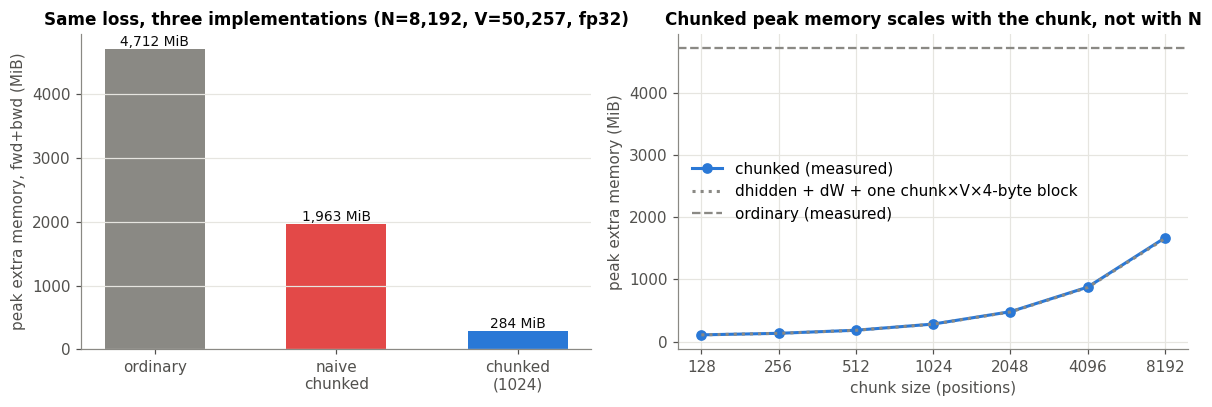

In [23]:
if device == "cuda":
    sweep_chunks = [128, 256, 512, 1024, 2048, 4096, 8192]
    sweep = []
    for c in sweep_chunks:
        r = measure(lambda h, W, t: chunked_ce(h, W, t, c), h_mem, W_mem, t_mem, reps=3)
        sweep.append({"chunk": c, "peak_MiB": r["peak_bytes"] / MiB, "ms": r["ms"], "|loss - ordinary|": abs(r["loss"] - ref["loss"])})
        del r
    sweep_df = pd.DataFrame(sweep).set_index("chunk")
    display(sweep_df.style.format({"peak_MiB": "{:,.1f}", "ms": "{:.0f}", "|loss - ordinary|": "{:.1e}"}))

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    ax = axes[0]
    names = ["ordinary", "naive\nchunked", f"chunked\n({chunk})"]
    vals = [r["peak_bytes"] / MiB for r in res.values()]
    bars = ax.bar(names, vals, color=[C_REF, C_BUG, C_T1], width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,.0f} MiB", ha="center", va="bottom", fontsize=9, color="#0b0b0b")
    ax.set_ylabel("peak extra memory, fwd+bwd (MiB)")
    ax.set_title(f"Same loss, three implementations (N={N:,}, V={V:,}, fp32)")
    ax.grid(axis="x", visible=False)
    ax = axes[1]
    ax.plot(sweep_df.index, sweep_df["peak_MiB"], marker="o", color=C_T1, label="chunked (measured)")
    grads_MiB = (N * D + V * D) * 4 / MiB                     # dhidden + dW, allocated by every implementation
    ax.plot(sweep_df.index, [grads_MiB + c * V * 4 / MiB for c in sweep_chunks], ls=":", color=C_REF,
            label="dhidden + dW + one chunk×V×4-byte block")
    ax.axhline(ref["peak_bytes"] / MiB, color=C_REF, ls="--", lw=1.5, label="ordinary (measured)")
    ax.set_xscale("log", base=2); ax.set_xticks(sweep_chunks); ax.set_xticklabels([str(c) for c in sweep_chunks])
    ax.set_xlabel("chunk size (positions)"); ax.set_ylabel("peak extra memory (MiB)")
    ax.set_title("Chunked peak memory scales with the chunk, not with N")
    ax.legend(loc="center left")
    plt.tight_layout(); plt.savefig(FIGS / "chunked_ce_memory.png"); plt.show()

    key_chunked = f"chunked, chunk={chunk} (recompute in backward)"
    METRICS["chunked_ce"] = {
        "N_positions": N, "D": D, "V": V, "dtype": "float32", "chunk": chunk,
        "ordinary_peak_MiB": res["ordinary"]["peak_bytes"] / MiB,
        "naive_chunked_peak_MiB": res["naive chunked (autograd keeps every chunk)"]["peak_bytes"] / MiB,
        "chunked_peak_MiB": res[key_chunked]["peak_bytes"] / MiB,
        "ratio_ordinary_over_chunked": res["ordinary"]["peak_bytes"] / res[key_chunked]["peak_bytes"],
        "ordinary_loss": res["ordinary"]["loss"], "chunked_loss": res[key_chunked]["loss"],
        "abs_loss_diff": abs(res["ordinary"]["loss"] - res[key_chunked]["loss"]),
        "max_abs_dhidden_diff": mem_df.loc[key_chunked, "max |dhidden - ordinary|"],
        "max_abs_dW_diff": mem_df.loc[key_chunked, "max |dW - ordinary|"],
        "ordinary_ms": res["ordinary"]["ms"], "chunked_ms": res[key_chunked]["ms"],
        "one_full_logits_tensor_MiB": N * V * 4 / MiB, "one_chunk_block_MiB": chunk * V * 4 / MiB,
        "gradcheck_float64": bool(gradcheck_ok),
        "sweep": {int(c): {"peak_MiB": float(r.peak_MiB), "ms": float(r.ms)} for c, r in sweep_df.iterrows()},
    }
    del res, h_mem, W_mem

The same comparison inside a **whole training step** (fp32 forward and backward of the full model on the same
batch). This includes parameters' gradients and the trunk's activations, which no loss implementation can remove.

In [24]:
def step_peak(model, tokens, doc, impl):
    model.zero_grad(set_to_none=True)
    torch.cuda.synchronize(); gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    base = torch.cuda.memory_allocated()
    hidden, _ = model(tokens, doc, with_logits=False)
    tgt = build_targets(tokens, 1, doc_ids=doc).reshape(-1)
    h2 = hidden.reshape(-1, D)
    loss = ordinary_ce(h2, model.heads[0].weight, tgt) if impl == "ordinary" else chunked_ce(h2, model.heads[0].weight, tgt, CFG["ce_chunk"])
    loss.backward(); torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() - base
    model.zero_grad(set_to_none=True)
    return loss.item(), peak

if device == "cuda":
    for impl in ("ordinary", "chunked"):           # warm-up
        step_peak(model0, tokens_b, docs_b, impl)
    step_rows = {impl: step_peak(model0, tokens_b, docs_b, impl) for impl in ("ordinary", "chunked")}
    step_df = pd.DataFrame({impl: {"loss": l, "peak extra memory (MiB)": p / MiB} for impl, (l, p) in step_rows.items()}).T
    display(step_df)
    METRICS["chunked_ce"]["full_step_fp32"] = {
        "ordinary_peak_MiB": step_rows["ordinary"][1] / MiB, "chunked_peak_MiB": step_rows["chunked"][1] / MiB,
        "ratio": step_rows["ordinary"][1] / step_rows["chunked"][1],
        "ordinary_loss": step_rows["ordinary"][0], "chunked_loss": step_rows["chunked"][0]}
    print(f"whole-step peak ratio ordinary/chunked: {step_rows['ordinary'][1] / step_rows['chunked'][1]:.2f}x")

,loss,peak extra memory (MiB)
ordinary,10.909390,6285.250977
chunked,10.909389,1857.313477


whole-step peak ratio ordinary/chunked: 3.38x


**Reading the memory results.** The chunked loss agrees with the ordinary one to float precision, in both the loss
and the gradients, so the objective is unchanged. Its peak is the fixed gradient buffers plus one `[chunk, V]`
block, which the sweep confirms, and it no longer grows with the number of positions. The naive loop sits in
between. It avoids some of the ordinary path's full-size temporaries, but autograd still keeps a full `[N, V]`
tensor's worth of chunk outputs for backward, so its peak still grows with `N`. The recompute in backward is what
makes the memory independent of `N`. The price is time: the head matmul runs once more, in smaller pieces.

# Part 2 — a second head that predicts `t+2`

`heads[1]` reads the same final hidden state as `heads[0]` and is trained against the token **two** positions
ahead: `build_targets(tokens, k=2, doc_ids=...)`. Its legitimate positions are fewer:

* the last **two** positions of every window have no `t+2` inside it;
* at a document boundary **two** `t+2` targets cross into the next document (the token just before
  `<|endoftext|>` and `<|endoftext|>` itself), against one for `t+1`;
* with padding, the last two real positions of a short sequence lose their `t+2` target.

The tables below are produced by the same `build_targets` the training loop calls.

In [25]:
print("t+1 and t+2 targets for the sentence (last two rows show the end-of-window masking):")
display(alignment_table(sent_ids, ks=(1, 2)))
print("around the packed-document boundary:")
display(alignment_table(pack_tokens[0], ks=(1, 2), doc_row=pack_docs[0], positions=range(jb - 3, jb + 3)))
print("padding (shortest sentence):")
display(alignment_table(pad_tokens[3], ks=(1, 2), valid_row=pad_valid[3]))

for name, (tok, kw) in {"sentence": (sent_ids[None], {}), "packed pair": (pack_tokens, {"doc_ids": pack_docs}),
                        "padded batch": (pad_tokens, {"valid": pad_valid}), "validation batch": (tokens_b, {"doc_ids": docs_b})}.items():
    for k in (1, 2):
        ok, msg = check_alignment(tok, build_targets(tok, k, **kw), k)
        assert ok, (name, k, msg)
print("check_alignment passed for k=1 and k=2 on the sentence, packed pair, padded batch and a validation batch")
METRICS["t2_table"] = [{"t": t, "input": tok_str(sent_ids[t]),
                        "target_t+1": tok_str(sent_ids[t + 1]) if t + 1 < len(sent_ids) else None,
                        "target_t+2": tok_str(sent_ids[t + 2]) if t + 2 < len(sent_ids) else None} for t in range(len(sent_ids))]

t+1 and t+2 targets for the sentence (last two rows show the end-of-window masking):


,input,t+1 target,t+2 target
t,,,
0,"""The""",""" capital""",""" of"""
1,""" capital""",""" of""",""" India"""
2,""" of""",""" India""",""" is"""
3,""" India""",""" is""",""" New"""
4,""" is""",""" New""",""" Delhi"""
5,""" New""",""" Delhi""",""","""
6,""" Delhi""",""",""",""" and"""
7,""",""",""" and""",""" the"""
8,""" and""",""" the""",""" Parliament"""


around the packed-document boundary:


,input,doc,t+1 target,t+2 target
t,,,,
14,""" of""",0,""" India""","""."""
15,""" India""",0,""".""","""<|endoftext|>"""
16,""".""",0,"""<|endoftext|>""",— masked (doc boundary)
17,"""<|endoftext|>""",0,— masked (doc boundary),— masked (doc boundary)
18,"""Photos""",1,"""ynthesis""",""" lets"""
19,"""ynthesis""",1,""" lets""",""" plants"""


padding (shortest sentence):


,input,t+1 target,t+2 target
t,,,
0,"""Hello""",""" world""","""."""
1,""" world""",""".""",— masked (padding)
2,""".""",— masked (padding),— masked (padding)
3,"""<|endoftext|>"" (pad)",— masked (padding),— masked (padding)
4,"""<|endoftext|>"" (pad)",— masked (padding),— masked (padding)
5,"""<|endoftext|>"" (pad)",— masked (padding),— masked (padding)
6,"""<|endoftext|>"" (pad)",— masked (padding),— masked (padding)
7,"""<|endoftext|>"" (pad)",— masked (padding),— masked (padding)
8,"""<|endoftext|>"" (pad)",— masked (padding),— masked (padding)


check_alignment passed for k=1 and k=2 on the sentence, packed pair, padded batch and a validation batch


**Denominators.** In a packed batch, the number of contributing positions per head can be predicted independently
of `build_targets`: `n₁ = B(T−1) − (#boundaries)`, and `n₂ = B(T−2) − Σ over boundaries of [boundary not at the
window start] + [boundary not in the last two positions]`. Each boundary removes one `t+1` target and up to two
`t+2` targets. The cell checks this on the first training batch.

In [26]:
def predicted_counts(doc):
    starts = (doc[:, 1:] != doc[:, :-1]).nonzero(as_tuple=True)[1] + 1          # j: first position of a new document
    n1 = doc.shape[0] * (T - 1) - len(starts)
    n2 = doc.shape[0] * (T - 2) - int(((starts >= 2).long() + (starts <= T - 2).long()).sum())
    return n1, n2

tb, db = train_split.get(torch.arange(B))
n1_pred, n2_pred = predicted_counts(db)
n1_real = int((build_targets(tb, 1, doc_ids=db) != IGNORE).sum()); n2_real = int((build_targets(tb, 2, doc_ids=db) != IGNORE).sum())
print(f"t+1 contributing: predicted {n1_pred:,}, build_targets {n1_real:,}   (of B*(T-1) = {B*(T-1):,})")
print(f"t+2 contributing: predicted {n2_pred:,}, build_targets {n2_real:,}   (of B*(T-2) = {B*(T-2):,})")
assert (n1_pred, n2_pred) == (n1_real, n2_real), "this formula assumes no document shorter than 2 tokens inside the batch"
METRICS["denominators_first_train_batch"] = {"n1": n1_real, "n2": n2_real, "B*(T-1)": B * (T - 1), "B*(T-2)": B * (T - 2)}

t+1 contributing: predicted 8,149, build_targets 8,149   (of B*(T-1) = 8,160)
t+2 contributing: predicted 8,106, build_targets 8,106   (of B*(T-2) = 8,128)


## 2.1 Training

Three runs, all from the same initial weights (same seed; the t+2 head is created last, so every shared parameter
starts identical) and the same shuffled data order:

| run | heads | objective | steps |
|---|---|---|---|
| `baseline` | t+1 | L₁ | one pass over the training windows |
| `mtp` | t+1 and t+2 | **L₁ + L₂** (a plain sum, equal weights) | same |
| `wrong_shift` | t+1 | L₁ with targets built by `k = −1` (the shift in the wrong direction) | 300 |

AdamW (β = 0.9/0.95, weight decay 0.1 on matrices), 100 warmup steps then cosine from 1e-3 to 1e-4, gradient
clipping at 1.0, fp16 autocast with a gradient scaler. Validation losses use the first 40 validation batches and the
same harness (document masks on). Training uses the ordinary cross-entropy, which fits on a T4 in fp16; 1.7 showed
the chunked path computes the same objective.

At step 0 of every run, before any update, the training loop calls `check_alignment` on the targets it is about to
train on, and raises if they are wrong. The wrong-shift control is the one run allowed past that check, so that it
can be observed.

In [27]:
def lr_at(step, total):
    if step < CFG["warmup_steps"]:
        return CFG["max_lr"] * (step + 1) / CFG["warmup_steps"]
    p = (step - CFG["warmup_steps"]) / max(1, total - CFG["warmup_steps"])
    return CFG["min_lr"] + 0.5 * (CFG["max_lr"] - CFG["min_lr"]) * (1 + math.cos(math.pi * p))


def train(name, n_future, steps, head_ks=None, deliberately_wrong=False):
    head_ks = head_ks or list(range(1, n_future + 1))
    seed_everything()
    model = GPT(CFG, tied=True, n_future=n_future).to(device)
    decay = [p for p in model.parameters() if p.dim() >= 2]
    no_decay = [p for p in model.parameters() if p.dim() < 2]
    opt = torch.optim.AdamW([{"params": decay, "weight_decay": CFG["weight_decay"]}, {"params": no_decay, "weight_decay": 0.0}],
                            lr=CFG["max_lr"], betas=(0.9, 0.95), fused=(device == "cuda"))
    scaler = torch.amp.GradScaler(device, enabled=(device == "cuda"))
    order = torch.randperm(train_split.n_windows, generator=torch.Generator().manual_seed(SEED))
    step_log, eval_log, t0 = [], [], time.time()
    eval_ks = [1] if deliberately_wrong else head_ks
    for step in range(steps + 1):
        if step % CFG["eval_every"] == 0 or step == steps:
            vl, _ = evaluate(model, val_split, CFG["eval_batches"], eval_ks)
            eval_log.append({"step": step, "tokens": step * B * T, **{f"val_L{k}": v for k, v in vl.items()}})
        if step == steps:
            break
        tokens, doc = train_split.get(order[step * B:(step + 1) * B])
        targets = [build_targets(tokens, k, doc_ids=doc) for k in head_ks]
        if step == 0:
            for k, tg in zip(head_ks, targets):
                intended = 1 if deliberately_wrong else k
                ok, msg = check_alignment(tokens, tg, intended)
                print(f"[{name}] step-0 alignment guard, head predicting t+{intended}: {'PASS' if ok else 'FAIL'} - {msg}")
                if not ok and not deliberately_wrong:
                    raise RuntimeError(f"target alignment broken in run {name}: {msg}")
        for pg in opt.param_groups:
            pg["lr"] = lr_at(step, steps)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device == "cuda")):
            _, logits = model(tokens, doc)
        losses, counts = [], []
        for lg, tg in zip(logits, targets):
            l, n, _ = masked_ce(lg, tg)
            losses.append(l); counts.append(n)
        loss = sum(losses)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
        scaler.step(opt); scaler.update()
        row = {"step": step + 1, "tokens": (step + 1) * B * T, "lr": opt.param_groups[0]["lr"], "grad_norm": gnorm.item()}
        for k, l, n in zip(head_ks, losses, counts):
            row[f"train_L{k}"] = l.item(); row[f"n{k}"] = int(n)
        step_log.append(row)
        if (step + 1) % max(1, steps // 10) == 0:
            parts = "  ".join(f"L{k}={row[f'train_L{k}']:.3f}" for k in head_ks)
            print(f"[{name}] step {step + 1:5d}/{steps}  {parts}  {(time.time() - t0) / (step + 1) * 1e3:.0f} ms/step")
    secs = time.time() - t0
    steps_df, evals_df = pd.DataFrame(step_log), pd.DataFrame(eval_log)
    steps_df.to_csv(RESULTS / f"train_log_{name}.csv", index=False)
    evals_df.to_csv(RESULTS / f"val_log_{name}.csv", index=False)
    del opt
    return model, steps_df, evals_df, secs

steps_full = train_split.n_windows // B
print(f"one pass = {steps_full:,} steps x {B * T:,} tokens = {steps_full * B * T:,} tokens")
del model0; gc.collect(); torch.cuda.empty_cache() if device == "cuda" else None

one pass = 2,467 steps x 8,192 tokens = 20,209,664 tokens


In [28]:
base_model, base_steps, base_evals, base_secs = train("baseline", n_future=1, steps=steps_full)
print(f"baseline: {base_secs / 60:.1f} min")
print(f"step-0 val L1 of the baseline run {base_evals['val_L1'].iloc[0]:.5f} vs the untrained loss in 1.5 {L0:.5f}")
assert abs(base_evals["val_L1"].iloc[0] - L0) < 1e-3, "the training run does not start from the model checked in 1.5"

[baseline] step-0 alignment guard, head predicting t+1: PASS - all 8,154 contributing targets are the token exactly 1 position(s) later


[baseline] step   246/2467  L1=6.294  307 ms/step


[baseline] step   492/2467  L1=6.000  299 ms/step


[baseline] step   738/2467  L1=5.926  301 ms/step


[baseline] step   984/2467  L1=5.640  298 ms/step


...

[baseline] step  1722/2467  L1=5.126  299 ms/step


[baseline] step  1968/2467  L1=5.062  297 ms/step


[baseline] step  2214/2467  L1=5.152  298 ms/step


[baseline] step  2460/2467  L1=5.100  298 ms/step


baseline: 12.3 min
step-0 val L1 of the baseline run 10.92150 vs the untrained loss in 1.5 10.92150


In [29]:
mtp_model, mtp_steps, mtp_evals, mtp_secs = train("mtp", n_future=2, steps=steps_full)
print(f"mtp: {mtp_secs / 60:.1f} min")
print(f"step-0 val L1: mtp {mtp_evals['val_L1'].iloc[0]:.5f} vs baseline {base_evals['val_L1'].iloc[0]:.5f}")
assert abs(mtp_evals["val_L1"].iloc[0] - base_evals["val_L1"].iloc[0]) < 1e-3, "runs do not share the initial trunk"

[mtp] step-0 alignment guard, head predicting t+1: PASS - all 8,154 contributing targets are the token exactly 1 position(s) later
[mtp] step-0 alignment guard, head predicting t+2: PASS - all 8,116 contributing targets are the token exactly 2 position(s) later


[mtp] step   246/2467  L1=6.307  L2=7.082  521 ms/step


[mtp] step   492/2467  L1=5.990  L2=6.922  507 ms/step


[mtp] step   738/2467  L1=5.930  L2=6.894  511 ms/step


[mtp] step   984/2467  L1=5.680  L2=6.734  506 ms/step


...

[mtp] step  1722/2467  L1=5.176  L2=6.340  508 ms/step


[mtp] step  1968/2467  L1=5.124  L2=6.244  506 ms/step


[mtp] step  2214/2467  L1=5.224  L2=6.403  507 ms/step


[mtp] step  2460/2467  L1=5.171  L2=6.375  506 ms/step


mtp: 20.9 min
step-0 val L1: mtp 10.92150 vs baseline 10.92150


In [30]:
wrong_model, wrong_steps, wrong_evals, wrong_secs = train("wrong_shift", n_future=1, steps=CFG["wrong_shift_steps"],
                                                          head_ks=[-1], deliberately_wrong=True)
print(f"wrong_shift: {wrong_secs / 60:.1f} min")
METRICS["runtime_minutes"] = {"baseline": base_secs / 60, "mtp": mtp_secs / 60, "wrong_shift": wrong_secs / 60}

[wrong_shift] step-0 alignment guard, head predicting t+1: FAIL - 8,107 of 8,154 targets are NOT the token 1 position(s) later (32 of them point outside the window)


[wrong_shift] step    30/300  L-1=8.775  385 ms/step


[wrong_shift] step    60/300  L-1=7.364  322 ms/step


[wrong_shift] step    90/300  L-1=6.551  301 ms/step


[wrong_shift] step   120/300  L-1=5.459  322 ms/step


...

[wrong_shift] step   210/300  L-1=2.455  313 ms/step


[wrong_shift] step   240/300  L-1=1.940  306 ms/step


[wrong_shift] step   270/300  L-1=1.616  301 ms/step


[wrong_shift] step   300/300  L-1=1.409  296 ms/step


wrong_shift: 1.5 min


## 2.2 The wrong-direction shift: a beautiful curve

The control run trains on `target[t] = token[t−1]`, which is the textbook slicing written the other way round.
The causal model can see `t−1`, so the task reduces to copying, and the loss collapses. The step-0 guard flagged it
before the first update (printed above). Below, its training curve next to the correct baseline's first steps, and
its loss once it is scored against the **correct** next-token targets.

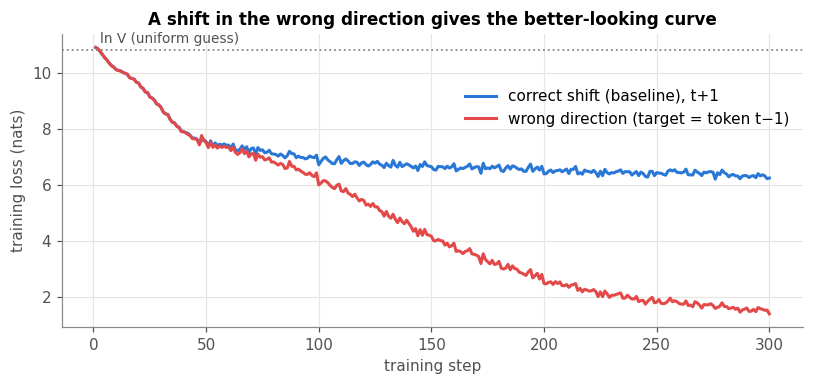

,nats
"wrong-shift run, training loss at step 300",1.409022
"correct baseline, training loss at step 300",6.259594
wrong-shift model scored on CORRECT t+1 targets (val),12.544960
correct baseline val L1 at step 300,6.421964


In [31]:
n_w = CFG["wrong_shift_steps"]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(base_steps["step"][:n_w], base_steps["train_L1"][:n_w], color=C_T1, label="correct shift (baseline), t+1")
ax.plot(wrong_steps["step"], wrong_steps["train_L-1"], color=C_BUG, label="wrong direction (target = token t−1)")
ax.axhline(math.log(V), color=C_REF, ls=":", lw=1.2)
ax.text(n_w * 0.01, math.log(V) + 0.15, "ln V (uniform guess)", va="bottom", fontsize=9, color="#52514e")
ax.set_xlabel("training step"); ax.set_ylabel("training loss (nats)")
ax.set_title("A shift in the wrong direction gives the better-looking curve")
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.86))
plt.tight_layout(); plt.savefig(FIGS / "wrong_shift_control.png"); plt.show()

wrong_correct_eval, _ = evaluate(wrong_model, val_split, CFG["eval_batches"], [1])
base_at_same_step = base_evals.loc[base_evals["step"] == n_w, "val_L1"]
wrong_report = {
    f"wrong-shift run, training loss at step {n_w}": float(wrong_steps["train_L-1"].iloc[-1]),
    f"correct baseline, training loss at step {n_w}": float(base_steps["train_L1"].iloc[n_w - 1]),
    "wrong-shift model scored on CORRECT t+1 targets (val)": wrong_correct_eval[1],
    f"correct baseline val L1 at step {n_w}": float(base_at_same_step.iloc[0]) if len(base_at_same_step) else float("nan"),
}
display(pd.Series(wrong_report).to_frame("nats"))
METRICS["wrong_shift_control"] = wrong_report

## 2.3 t+1 and t+2 losses over training

Validation losses of both heads of the `mtp` run, the summed objective, and the `baseline` run's single head for
reference. Training curves (lighter) are smoothed with a 50-step moving average.

**A model-free check on the size of the gap.** Before reading the curves: how much harder is `t+2` than `t+1` in
this data, with no neural network involved? Count-based models are built from the training windows (pairs inside
the same document only) and scored on the same 40 validation batches:

* **unigram** `p(x)`: no context, so it is the same number for both targets;
* **bigram** `p(x_{t+1} | x_t)`, interpolated with the unigram;
* **skip-bigram** `p(x_{t+2} | x_t)`, interpolated the same way.

The interpolation weight is chosen on the validation pairs from a small grid, by the same procedure for both, so
the comparison is fair even though both numbers are slightly optimistic.

In [32]:
def pairs(tokens, doc_ids, k):
    a, b = tokens[:, :-k].reshape(-1).numpy(), tokens[:, k:].reshape(-1).numpy()
    same = (doc_ids[:, :-k] == doc_ids[:, k:]).reshape(-1).numpy()
    return a[same], b[same]

def count_model(k, lams=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9)):
    a, b = pairs(train_split.tokens, train_split.doc_ids, k)
    keys, counts = np.unique(a * V + b, return_counts=True)
    ctx = np.bincount(a, minlength=V).astype(np.float64)
    uni = (np.bincount(b, minlength=V) + 1.0) / (len(b) + V)             # add-one unigram
    nv = CFG["eval_batches"] * B
    va, vb = pairs(val_split.tokens[:nv], val_split.doc_ids[:nv], k)
    vk = va * V + vb
    pos = np.minimum(np.searchsorted(keys, vk), len(keys) - 1)
    c_ab = np.where(keys[pos] == vk, counts[pos], 0).astype(np.float64)
    c_a = ctx[va]
    p_ctx = np.divide(c_ab, c_a, out=np.zeros_like(c_ab), where=c_a > 0)
    ce = {}
    for lam in lams:
        w = np.where(c_a > 0, lam, 0.0)
        ce[lam] = float(-np.log(w * p_ctx + (1 - w) * uni[vb]).mean())
    best = min(ce, key=ce.get)
    return {"ce": ce[best], "lambda": best, "unigram_ce": float(-np.log(uni[vb]).mean()), "val_pairs": len(vb)}

ng1, ng2 = count_model(1), count_model(2)
NG = {"unigram (no context)": ng1["unigram_ce"], "bigram  p(x_t+1 | x_t)": ng1["ce"], "skip-bigram  p(x_t+2 | x_t)": ng2["ce"],
      "skip-bigram - bigram gap": ng2["ce"] - ng1["ce"]}
display(pd.Series(NG).to_frame("val CE (nats)").style.format("{:.3f}"))
print(f"interpolation weights: bigram {ng1['lambda']}, skip-bigram {ng2['lambda']}; scored pairs {ng1['val_pairs']:,} / {ng2['val_pairs']:,}")
METRICS["count_models"] = {"unigram_ce": ng1["unigram_ce"], "bigram_ce": ng1["ce"], "skip_bigram_ce": ng2["ce"],
                           "gap": ng2["ce"] - ng1["ce"], "lambda_bigram": ng1["lambda"], "lambda_skip": ng2["lambda"]}

,val CE (nats)
unigram (no context),7.678
bigram p(x_t+1 | x_t),6.047
skip-bigram p(x_t+2 | x_t),7.215
skip-bigram - bigram gap,1.169


interpolation weights: bigram 0.8, skip-bigram 0.5; scored pairs 326,058 / 324,436


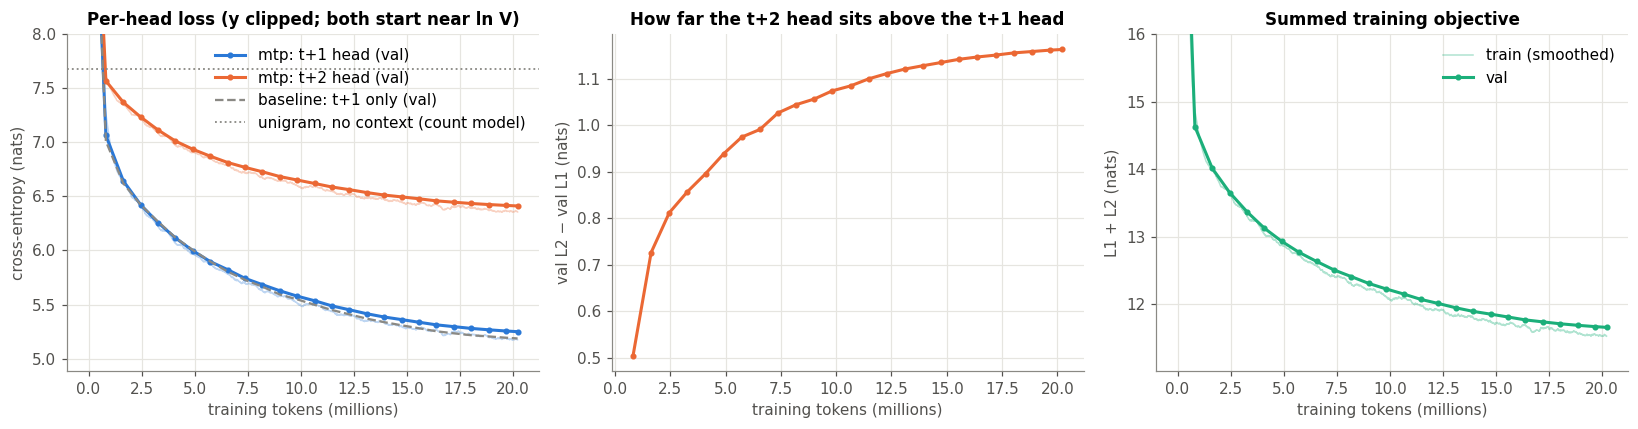

In [33]:
def smooth(s, w=50):
    return s.rolling(w, min_periods=1).mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ax = axes[0]
ax.plot(mtp_steps["tokens"] / 1e6, smooth(mtp_steps["train_L1"]), color=C_T1, alpha=0.3, lw=1)
ax.plot(mtp_steps["tokens"] / 1e6, smooth(mtp_steps["train_L2"]), color=C_T2, alpha=0.3, lw=1)
ax.plot(mtp_evals["tokens"] / 1e6, mtp_evals["val_L1"], color=C_T1, marker="o", ms=3, label="mtp: t+1 head (val)")
ax.plot(mtp_evals["tokens"] / 1e6, mtp_evals["val_L2"], color=C_T2, marker="o", ms=3, label="mtp: t+2 head (val)")
ax.plot(base_evals["tokens"] / 1e6, base_evals["val_L1"], color=C_REF, ls="--", lw=1.5, label="baseline: t+1 only (val)")
ax.axhline(ng1["unigram_ce"], color=C_REF, ls=":", lw=1.2, label="unigram, no context (count model)")
ax.set_ylim(top=max(8.0, mtp_evals["val_L2"].iloc[1] + 0.3) if len(mtp_evals) > 1 else None)
ax.set_xlabel("training tokens (millions)"); ax.set_ylabel("cross-entropy (nats)")
ax.set_title("Per-head loss (y clipped; both start near ln V)"); ax.legend(loc="upper right")
ax = axes[1]
gap = mtp_evals["val_L2"] - mtp_evals["val_L1"]
ax.plot(mtp_evals["tokens"][1:] / 1e6, gap[1:], color=C_T2, marker="o", ms=3)
ax.set_xlabel("training tokens (millions)"); ax.set_ylabel("val L2 − val L1 (nats)")
ax.set_title("How far the t+2 head sits above the t+1 head")
ax = axes[2]
ax.plot(mtp_steps["tokens"] / 1e6, smooth(mtp_steps["train_L1"] + mtp_steps["train_L2"]), color=C_SUM, alpha=0.35, lw=1, label="train (smoothed)")
ax.plot(mtp_evals["tokens"] / 1e6, mtp_evals["val_L1"] + mtp_evals["val_L2"], color=C_SUM, marker="o", ms=3, label="val")
ax.set_ylim(top=max(16.0, (mtp_evals["val_L1"] + mtp_evals["val_L2"]).iloc[1] + 0.5) if len(mtp_evals) > 1 else None)
ax.set_xlabel("training tokens (millions)"); ax.set_ylabel("L1 + L2 (nats)")
ax.set_title("Summed training objective"); ax.legend(loc="upper right")
plt.tight_layout(); plt.savefig(FIGS / "training_losses.png"); plt.show()

In [34]:
ev = mtp_evals.set_index("step")
final = ev.iloc[-1]
first = ev.iloc[0]
checkpoints = [s for s in ev.index if s in (0, 100, 200, 500, 1000, 1500, 2000) or s == ev.index[-1]]
traj = pd.DataFrame({"tokens (M)": ev.loc[checkpoints, "tokens"] / 1e6,
                     "val L1 (t+1)": ev.loc[checkpoints, "val_L1"], "val L2 (t+2)": ev.loc[checkpoints, "val_L2"],
                     "L2 − L1": ev.loc[checkpoints, "val_L2"] - ev.loc[checkpoints, "val_L1"],
                     "L2 / L1": ev.loc[checkpoints, "val_L2"] / ev.loc[checkpoints, "val_L1"],
                     "baseline val L1": base_evals.set_index("step").loc[checkpoints, "val_L1"]})
display(traj.style.format("{:.3f}"))

def frac_of_drop(series, at_step):
    """Fraction of the run's total loss drop achieved by at_step."""
    return (series.iloc[0] - series.loc[at_step]) / (series.iloc[0] - series.iloc[-1])

quarter = min(ev.index, key=lambda s: abs(s - ev.index[-1] / 4))
tail_window = [s for s in ev.index if s >= ev.index[-1] / 2]
part2 = {
    "final val L1 (t+1 head, mtp)": float(final["val_L1"]), "final val L2 (t+2 head, mtp)": float(final["val_L2"]),
    "final val L1 + L2": float(final["val_L1"] + final["val_L2"]),
    "final val L1 (baseline, no t+2 head)": float(base_evals["val_L1"].iloc[-1]),
    "L1(mtp) - L1(baseline)": float(final["val_L1"] - base_evals["val_L1"].iloc[-1]),
    "final train L1 (last 50 steps, mtp)": float(mtp_steps["train_L1"].tail(50).mean()),
    "final train L2 (last 50 steps, mtp)": float(mtp_steps["train_L2"].tail(50).mean()),
    "initial val L1": float(first["val_L1"]), "initial val L2": float(first["val_L2"]),
    "total drop L1": float(first["val_L1"] - final["val_L1"]), "total drop L2": float(first["val_L2"] - final["val_L2"]),
    f"fraction of total drop reached by step {quarter}, L1": float(frac_of_drop(ev["val_L1"], quarter)),
    f"fraction of total drop reached by step {quarter}, L2": float(frac_of_drop(ev["val_L2"], quarter)),
    "drop over 2nd half of training, L1": float(ev.loc[tail_window[0], "val_L1"] - final["val_L1"]),
    "drop over 2nd half of training, L2": float(ev.loc[tail_window[0], "val_L2"] - final["val_L2"]),
    "final perplexity t+1 (mtp)": math.exp(final["val_L1"]), "final perplexity t+2 (mtp)": math.exp(final["val_L2"]),
    "final perplexity t+1 (baseline)": math.exp(base_evals["val_L1"].iloc[-1]),
    "max L2 - L1 gap (after step 0)": float(gap[1:].max()), "step of max gap": int(mtp_evals["step"][1:][gap[1:].idxmax()]),
    "final L2 - L1 gap": float(final["val_L2"] - final["val_L1"]),
}
display(pd.Series(part2).to_frame("value").style.format("{:.4f}"))
METRICS["part2"] = part2
METRICS["part2_trajectory"] = {int(s): {"val_L1": float(r["val L1 (t+1)"]), "val_L2": float(r["val L2 (t+2)"]),
                                        "baseline_val_L1": float(r["baseline val L1"])} for s, r in traj.iterrows()}

,tokens (M),val L1 (t+1),val L2 (t+2),L2 − L1,L2 / L1,baseline val L1
step,,,,,,
0,0.000,10.921,10.910,-0.012,0.999,10.921
100,0.819,7.063,7.568,0.504,1.071,7.010
200,1.638,6.644,7.370,0.726,1.109,6.621
500,4.096,6.116,7.012,0.896,1.146,6.118
1000,8.192,5.684,6.728,1.044,1.184,5.665
1500,12.288,5.452,6.563,1.111,1.204,5.409
2000,16.384,5.313,6.459,1.146,1.216,5.253
2467,20.210,5.249,6.412,1.162,1.221,5.187


,value
"final val L1 (t+1 head, mtp)",5.2493
"final val L2 (t+2 head, mtp)",6.4118
final val L1 + L2,11.6611
"final val L1 (baseline, no t+2 head)",5.1868
L1(mtp) - L1(baseline),0.0626
"final train L1 (last 50 steps, mtp)",5.1747
"final train L2 (last 50 steps, mtp)",6.3559
initial val L1,10.9215
initial val L2,10.9098
total drop L1,5.6722


**What the curves show.**

* At step 0 both heads sit at ln V. Nothing yet distinguishes one token ahead from two.
* In the first ~100 steps both drop past the **unigram** line, which is the same number for both targets. Token
  frequencies are the cheapest thing to learn and help both heads equally. Getting below that line requires using
  context, and already by step 100 the t+1 head is much further below it than the t+2 head.
* The gap `L2 − L1` (middle panel) widens through the whole run. The t+2 head is still improving at the end, but
  more slowly than the t+1 head.
* Why `t+2` is harder: the most informative single piece of context for token `t+2` is token `t+1`, and the t+2
  head never sees it. In entropy terms, `H(x_{t+2} | x_{≤t}) ≥ H(x_{t+2} | x_{≤t+1})`, and the right-hand side is an
  ordinary next-token entropy, so even a perfect t+2 head cannot beat a perfect t+1 head. The count models show
  the same ordering with no network at all: one token of context helps the skip-bigram far less than the bigram.
* Cost to the ordinary head: the `mtp` run's t+1 loss ends slightly **above** the `baseline` run that trained t+1
  alone (the `L1(mtp) − L1(baseline)` row). At this scale (30M parameters, 20M tokens, one dense extra head on a
  10.6M-parameter trunk) the second objective competes with the first for a small trunk. The usual case for MTP
  (denser supervision, and draft tokens at inference) is about larger models; this run does not test that regime.

# 3. The harness again, on trained models

Three things were deferred until training: what the boundary target looks like to a trained model, what padding
does to the mean once a model has opinions, and whether the trained heads predict what their targets say they
should.

### 3.1 Every document boundary in the validation set

Per-position t+1 cross-entropy of the trained `baseline` over the 40 validation batches, split into in-document
targets and boundary targets (`doc[t] ≠ doc[t+1]`). Every boundary target should start from `<|endoftext|>`, which
is asserted: the excluded transition is always "end of one document → first token of another".

,trained baseline
in-document targets,326058
boundary targets,342
mean CE in-document,5.186786
mean CE at boundaries,7.792147
"val loss, boundaries masked (reported)",5.186786
"val loss, boundaries included",5.189516
boundary inputs are all <|endoftext|>,True


,"trained baseline, packed pair from 1.4"
targets before masking,32
targets after masking,31
masked transition,"""<|endoftext|>"" -> ""Photos"""
CE of the boundary target,10.478567
loss before boundary mask,4.577637
loss after boundary mask,4.387284
difference (before - after),0.190353
predicted difference (boundary_ce - after)/n_before,0.190353
loss of A and B run separately,4.387284
"max |B logits packed - B alone|, doc-aware attention",0.000018


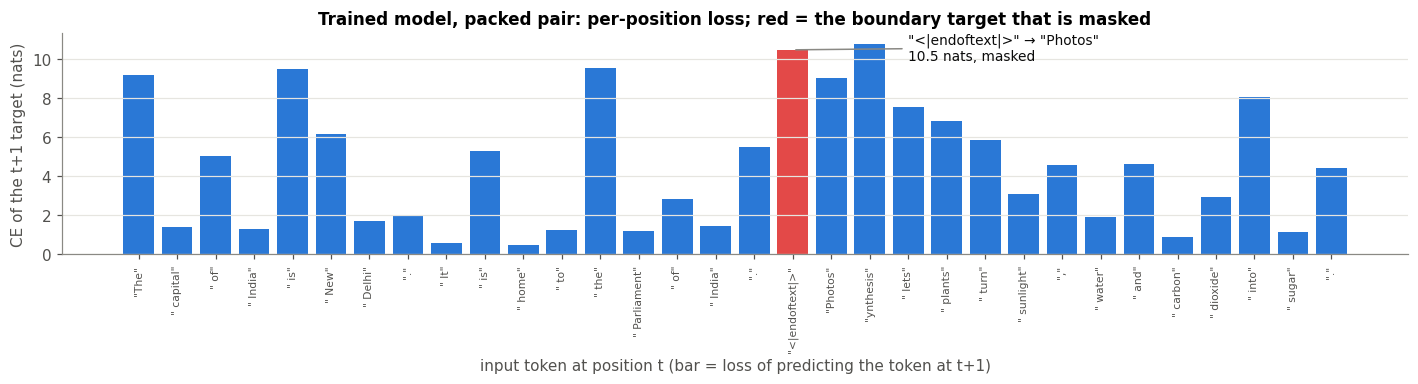

In [35]:
@torch.no_grad()
def boundary_stats(model, n_batches):
    model.eval()
    in_sum = in_n = bd_sum = bd_n = 0.0
    bd_inputs = set()
    for i in range(n_batches):
        tokens, doc = val_split.get(torch.arange(i * B, (i + 1) * B))
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device == "cuda")):
            _, (lg, *_) = model(tokens, doc)
        _, _, per_pos = masked_ce(lg, build_targets(tokens, 1))              # everything in-window, boundaries included
        is_bd = torch.zeros_like(tokens, dtype=torch.bool)
        is_bd[:, :-1] = doc[:, :-1] != doc[:, 1:]
        in_doc = torch.zeros_like(is_bd); in_doc[:, :-1] = ~is_bd[:, :-1]
        bd_inputs |= set(tokens[is_bd].unique().tolist())
        in_sum += per_pos[in_doc].sum().item(); in_n += in_doc.sum().item()
        bd_sum += per_pos[is_bd].sum().item(); bd_n += is_bd.sum().item()
    model.train()
    return {"in-document targets": int(in_n), "boundary targets": int(bd_n),
            "mean CE in-document": in_sum / in_n, "mean CE at boundaries": bd_sum / bd_n,
            "val loss, boundaries masked (reported)": in_sum / in_n,
            "val loss, boundaries included": (in_sum + bd_sum) / (in_n + bd_n),
            "boundary inputs are all <|endoftext|>": bd_inputs == {EOT}}

bstats = boundary_stats(base_model, CFG["eval_batches"])
display(pd.Series(bstats, name="trained baseline").to_frame())
assert bstats["boundary inputs are all <|endoftext|>"]
METRICS["boundaries_val_trained"] = bstats

pack_trained = packing_report(base_model)
display(pd.Series(pack_trained, name="trained baseline, packed pair from 1.4").to_frame())
METRICS["packing_trained"] = pack_trained

with torch.no_grad():
    base_model.eval()
    _, (lg_pack,) = base_model(pack_tokens, pack_docs)
    _, _, pp = masked_ce(lg_pack, build_targets(pack_tokens, 1))
    base_model.train()
ce = pp[0, :-1].float().cpu().numpy()
labels = [tok_str(i) for i in pack_tokens[0, :-1].tolist()]
fig, ax = plt.subplots(figsize=(13, 3.6))
colors = [C_BUG if t == jb else C_T1 for t in range(len(ce))]
ax.bar(range(len(ce)), ce, color=colors, width=0.8)
ax.set_xticks(range(len(ce))); ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_ylabel("CE of the t+1 target (nats)")
ax.set_xlabel("input token at position t (bar = loss of predicting the token at t+1)")
ax.set_title("Trained model, packed pair: per-position loss; red = the boundary target that is masked")
ax.annotate(f"{tok_str(pack_tokens[0, jb])} → {tok_str(pack_tokens[0, jb + 1])}\n{ce[jb]:.1f} nats, masked",
            xy=(jb, ce[jb]), xytext=(jb + 3, ce[jb] * 0.95), fontsize=9, color="#0b0b0b",
            arrowprops=dict(arrowstyle="-", color=C_REF, lw=1))
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.savefig(FIGS / "packed_boundary_trained.png"); plt.show()

To the trained model, boundary targets are much harder than in-document ones. That is the point: nothing in
document A says how document B begins. In this data they are also rare. FineWeb-Edu documents average about 1,000
tokens against a 256-token window, so about one window in four contains a boundary, and boundary targets are about
0.1% of all validation targets. Including them shifts the validation loss only in the third decimal here. In the
32-token packed pair the single boundary target moves the mean by roughly 0.2 nats. Shorter documents or longer
windows make the fraction, and the bias, larger. The masked number is the correct one either way.

### 3.2 Padding on the trained model

In [36]:
pad_trained = padding_report(base_model)
display(pd.DataFrame({"untrained": pad_untrained, "trained baseline": pad_trained}))
assert pad_trained["|masked - reference|"] < 1e-3
METRICS["padding_trained"] = pad_trained

,untrained,trained baseline
positions B*(L-1),6.800000e+01,6.800000e+01
contributing after mask,3.300000e+01,3.300000e+01
mean CE of the padding targets alone,9.673779e+00,1.060084e+01
loss unmasked,1.024202e+01,7.955282e+00
"loss masked, wrong denominator",5.262871e+00,2.498968e+00
"loss masked, correct",1.084470e+01,5.149388e+00
reference: sentences run alone,1.084470e+01,5.149388e+00
|masked - reference|,3.756899e-07,3.901395e-07


On the trained model the unmasked mean is far **higher** than the masked one, the reverse of 1.3. This model never
trained on any target that follows `<|endoftext|>` (those are boundary targets, so they were masked), and every
padding target is exactly that. The textbook version, where padding becomes trivially predictable and the loss
looks too good, is what happens to a model trained *without* the mask. The direction of the error depends on the
model; the masked mean is right in both cases, and it equals the no-padding reference.

### 3.3 Do the heads predict what their targets say?

The trained `mtp` model's greedy (top-1) prediction from each head on the 1.2 sentence, beside the targets. Then a
behavioural version of the shift check over 40 validation batches: how often each head's top-1 prediction equals
the token at `t+1`, at `t+2`, the **current** input token `t`, or the previous token `t−1`. A correctly shifted
model should be best at its own target. A model trained on the wrong shift should match `t−1` nearly always.

In [37]:
with torch.no_grad():
    mtp_model.eval()
    _, lg_s = mtp_model(sent_ids[None])
    mtp_model.train()
pred1, pred2 = lg_s[0][0].argmax(-1).tolist(), lg_s[1][0].argmax(-1).tolist()
display(alignment_table(sent_ids, ks=(1, 2), preds={"head 1 top-1": pred1, "head 2 top-1": pred2})[
    ["input", "t+1 target", "head 1 top-1", "t+2 target", "head 2 top-1"]])

@torch.no_grad()
def agreement(model, head, n_batches):
    model.eval()
    hits = {"t+1": [0, 0], "t+2": [0, 0], "t (copy current)": [0, 0], "t-1 (copy previous)": [0, 0]}
    for i in range(n_batches):
        tokens, doc = val_split.get(torch.arange(i * B, (i + 1) * B))
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device == "cuda")):
            _, lg = model(tokens, doc)
        pred = lg[head].argmax(-1)
        for name, k in (("t+1", 1), ("t+2", 2), ("t (copy current)", 0), ("t-1 (copy previous)", -1)):
            tg = build_targets(tokens, k, doc_ids=doc)
            m = tg != IGNORE
            hits[name][0] += int((pred[m] == tg[m]).sum()); hits[name][1] += int(m.sum())
    model.train()
    return {k: v[0] / v[1] for k, v in hits.items()}

agree = pd.DataFrame({"baseline head 1": agreement(base_model, 0, CFG["eval_batches"]),
                      "mtp head 1": agreement(mtp_model, 0, CFG["eval_batches"]),
                      "mtp head 2": agreement(mtp_model, 1, CFG["eval_batches"]),
                      "wrong-shift head 1": agreement(wrong_model, 0, CFG["eval_batches"])}).T
display(agree.style.format("{:.1%}"))
METRICS["top1_agreement"] = {r: {c: float(v) for c, v in row.items()} for r, row in agree.iterrows()}
expected = {"baseline head 1": "t+1", "mtp head 1": "t+1", "mtp head 2": "t+2", "wrong-shift head 1": "t-1 (copy previous)"}
for row, col in expected.items():
    print(f"{row:20s} best top-1 match: {agree.loc[row].idxmax():22s} (the target it was trained on: {col})")
METRICS["top1_best_match"] = {row: agree.loc[row].idxmax() for row in expected}
METRICS["trained_predictions_table"] = [{"t": t, "input": tok_str(sent_ids[t]), "head1_top1": tok_str(pred1[t]), "head2_top1": tok_str(pred2[t])}
                                        for t in range(len(sent_ids))]

,input,t+1 target,head 1 top-1,t+2 target,head 2 top-1
t,,,,,
0,"""The""",""" capital""",""" first""",""" of""",""" of"""
1,""" capital""",""" of""",""" of""",""" India""",""" the"""
2,""" of""",""" India""",""" the""",""" is""",""" is"""
3,""" India""",""" is""",""" is""",""" New""",""" the"""
4,""" is""",""" New""",""" the""",""" Delhi""",""" of"""
5,""" New""",""" Delhi""",""" Zealand""",""",""",""","""
6,""" Delhi""",""",""",""",""",""" and""",""" the"""
7,""",""",""" and""",""" the""",""" the""",""" is"""
8,""" and""",""" the""",""" the""",""" Parliament""",""" is"""


,t+1,t+2,t (copy current),t-1 (copy previous)
baseline head 1,22.6%,2.7%,0.0%,1.7%
mtp head 1,22.3%,3.0%,0.1%,1.7%
mtp head 2,3.5%,12.9%,2.8%,3.6%
wrong-shift head 1,0.8%,1.0%,0.7%,87.4%


baseline head 1      best top-1 match: t+1                    (the target it was trained on: t+1)
mtp head 1           best top-1 match: t+1                    (the target it was trained on: t+1)
mtp head 2           best top-1 match: t+2                    (the target it was trained on: t+2)
wrong-shift head 1   best top-1 match: t-1 (copy previous)    (the target it was trained on: t-1 (copy previous))


# 4. Results summary

The headline numbers, collected from the cells above and written to `results/metrics.json`.

In [38]:
cc = METRICS.get("chunked_ce", {})
part1 = pd.DataFrame([
    ("1 shapes", "logits / targets fed to CE", f"{METRICS['shapes']['logits[:, :-1].reshape(-1, V)']} / {METRICS['shapes']['tokens[:, 1:].reshape(-1)']}"),
    ("2 shift", "decoded + programmatic checks", f"{sum(v['passed'] for v in METRICS['shift_checks'].values())}/{len(METRICS['shift_checks'])} passed (incl. 2 negative controls)"),
    ("3 padding", "contributing positions, unmasked -> masked", f"{pad_untrained['positions B*(L-1)']} -> {pad_untrained['contributing after mask']}"),
    ("4 packing", "trained val loss, boundaries included -> masked", f"{bstats['val loss, boundaries included']:.4f} -> {bstats['val loss, boundaries masked (reported)']:.4f} ({bstats['boundary targets']:,} boundary targets, mean CE {bstats['mean CE at boundaries']:.2f})"),
    ("4 packing", "packed pair (trained), before -> after", f"{pack_trained['loss before boundary mask']:.4f} -> {pack_trained['loss after boundary mask']:.4f}"),
    ("5 perplexity", "untrained loss / perplexity vs V", f"{L0:.4f} / {math.exp(L0):,.0f} vs V = {V:,} (ln V = {math.log(V):.4f})"),
    ("6 tied vs untied", "parameters", f"{tied_n:,} vs {untied_n:,} (+{untied_n - tied_n:,})"),
    ("7 chunked CE", "peak extra MiB ordinary vs chunked, ratio",
     f"{cc.get('ordinary_peak_MiB', float('nan')):,.0f} vs {cc.get('chunked_peak_MiB', float('nan')):,.0f} MiB, {cc.get('ratio_ordinary_over_chunked', float('nan')):.1f}x; |dloss| = {cc.get('abs_loss_diff', float('nan')):.1e}"),
], columns=["item", "quantity", "value"]).set_index("item")
display(part1)
p2 = METRICS["part2"]
display(pd.Series({"val L1 (t+1)": p2["final val L1 (t+1 head, mtp)"], "val L2 (t+2)": p2["final val L2 (t+2 head, mtp)"],
                   "val L1 + L2": p2["final val L1 + L2"], "baseline val L1": p2["final val L1 (baseline, no t+2 head)"]}).to_frame("Part 2 (nats)"))

METRICS["config"] = CFG
METRICS["environment"] = ENV
(RESULTS / "metrics.json").write_text(json.dumps(METRICS, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o)))
print("wrote", RESULTS / "metrics.json")

,quantity,value
item,,
1 shapes,logits / targets fed to CE,"[8160, 50257] / [8160]"
2 shift,decoded + programmatic checks,5/5 passed (incl. 2 negative controls)
3 padding,"contributing positions, unmasked -> masked",68 -> 33
4 packing,"trained val loss, boundaries included -> masked","5.1895 -> 5.1868 (342 boundary targets, mean CE 7.79)"
4 packing,"packed pair (trained), before -> after",4.5776 -> 4.3873
5 perplexity,untrained loss / perplexity vs V,"10.9215 / 55,354 vs V = 50,257 (ln V = 10.8249)"
6 tied vs untied,parameters,"30,018,816 vs 49,317,504 (+19,298,688)"
7 chunked CE,"peak extra MiB ordinary vs chunked, ratio","4,712 vs 284 MiB, 16.6x; |dloss| = 9.5e-07"


,Part 2 (nats)
val L1 (t+1),5.249339
val L2 (t+2),6.411757
val L1 + L2,11.661096
baseline val L1,5.186786


wrote results/metrics.json
